# Prepare

In [26]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import qutip as qt
from copy import deepcopy

import experiments as meas
from experiments.MM_dual_rail_base import MM_dual_rail_base
from fitting.fit_display_classes import GeneralFitting
from fitting.wigner import WignerAnalysis

from slab import AttrDict
from experiments import MultimodeStation, CharacterizationRunner, SweepRunner

from job_server import JobClient
from job_server.database import get_database
from job_server.config_versioning import ConfigVersionManager

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
# Initialize database and config manager
db = get_database()
config_dir = 'C:/python/multimode_expts/configs'
config_manager = ConfigVersionManager(config_dir)

# Initialize job client (handle submitting and waiting for jobs)
client = JobClient()

# Check server health
health = client.health_check()
client.print_queue()


=== Job Queue ===

No job currently running

Pending: 0 jobs



In [28]:
config_dict = {'hardware_config': 'CFG-HW-20260905-00001',
 'multiphoton_config': 'CFG-MP-20260121-00001',
 'man1_storage_swap': 'CFG-M1-20260905-00001',
 'floquet_storage_swap': 'CFG-FL-20260905-00045'}



# Initialize station to retrieve soc and configs
station = MultimodeStation(
    user = 'Jonginn',
    experiment_name = "260701_Calibration",
    project = "AutoCalibrate",
    
    storage_man_file = config_dict['man1_storage_swap'],
    hardware_config= config_dict['hardware_config'],
    floquet_file=config_dict['floquet_storage_swap'],

    log_measurements=True,
)

[STATION] Using hardware_config version: CFG-HW-20260905-00001
[STATION] Using main multiphoton_config version: CFG-MP-20260121-00001
[STATION] Using man1_storage_swap version: CFG-M1-20260905-00001
[STATION] Using floquet_storage_swap version: CFG-FL-20260905-00045
[STATION] Lab-notebook vault: G:\Shared drives\SLab\Multimode
Data, plots, logs will be stored in: C:\experiments\260701_Calibration
Hardware configs will be read from C:\python\multimode_expts\configs\versions\hardware_config\CFG-HW-20260905-00001.yml
dict_keys(['Pyro.NameServer', 'Qick101'])
QICK running on ZCU216, software version 0.2.291

Firmware configuration (built Tue Oct 15 12:06:51 2024):

	Global clocks (MHz): tProcessor 430.080, RF reference 245.760

	7 signal generator channels:
	0:	axis_signal_gen_v6 - envelope memory 32768 samples (5.128 us)
		fs=6389.760 MHz, fabric=399.360 MHz, 32-bit DDS, range=6389.760 MHz
		DAC tile 2, blk 0 is 0_230, on JHC3
	1:	axis_signal_gen_v6 - envelope memory 32768 samples (5.128 

# Experiments to run

Depending on stage of cooldown, we will run a different sequence of calibration experiments. For example, amplitude rabi don't need to be updated every time, but the frequency correction from T2 is important to do every day. In the dictionary experiments to run, we will speciy the experiments we want to run. 

In [29]:

active_reset_default_dict = {
    "reset_dump_mode": 2,
    "dump_reset_iter_num": 1,
}

floquet_default_dict = {
    # For phase accumulation
    "include_10cycles_buffer": True,
    "include_10cycles_buffer_in_pi_half": True,
    "floquet_hardware_loop": True,
    "scramble_sync_cycles": 1,
    "palindrome_scramble": False,
}

USE_QUEUE = True

expts_to_run = {# readout 
                'res_spec': False, # Readout spectroscopy
                'single_shot': True, 
                
                
                # qubit ge 
                'pulse_probe_ge': False,
                't2_ge': False, 
                'amplitude_ge': False,
                't1_ge': False,
                'ge_freq_error_amplification': True,
                'ge_gain_error_amplification': True,
                
                
                # qubit ef
                'pulse_probe_ef': False,
                't2_ef': False,
                'amplitude_ef': False,
                't1_ef': False,
                'ef_freq_error_amplification': True,
                'ef_gain_error_amplification': True,
                
                # manipulate 
                'man_modes': [1], # [1,2] if also want to run mode 2
                'pulse_probe_f0g1': False,
                'man_freq_coarse_chevron': False,
                'man_freq_fine_chevron': False,
                'man_error_amplification': True,
                'length_rabi_sweep':True,
                'length_rabi':False, # this will run automatically if the length_rabi_sweep is set to True
                'chi_ge': False, 
                'chi_ef': False,
                'RB': False,
                'parity_delay_slow': True,
                'parity_delay_fast': False,
                't1_man': False,
                't2_man': False,
                

                #storage
                'stor_modes': [1, 2, 3, 4, 5, 6], # [1,2, .., 7] if also want to run  all modes 
                # 'stor_modes': [3, 4, 5], # [1,2, .., 7] if also want to run  all modes 
                'stor_spectroscopy': False,

                'dump_spectroscopy': False, #dump should be reivewed
                'dump_chevron': False, #dump should be reivewed
                'dump_modes': [1, 2],
                'dump_for_reset': active_reset_default_dict["reset_dump_mode"],

                'sideband_freq_sweep': False,
                'sideband_chevron': False,
                'sideband_erroramp': True,
                # 'storage_t1': True


                #Floquet
                'floquet_stor_modes': [1, 2, 3, 4],
                'floquet_chevron_coarse': False,
                'floquet_chevron_fine': False,
                'floquet_error_amplificaton_coarse': False,
                'floquet_error_amplificaton_fine': True,
                'floquet_phase_accumulation_matrix_coarse': False,
                'floquet_phase_accumulation_matrix_fine': True,
                'floquet_phase_accumulation_matrix_fine_bw': 4,
                
                
                
                #Multiphoton
                'multiphoton_fetch_from_singlequbit': False,
                'multiphoton_transitions': [
                                            'g1-e1', 
                                            'e1-f1', 
                                            'f1-g2',
                                            'g2-e2',
                                            'e2-f2',
                                            'f2-g3'],
                'sideband_pulse_probe_spectroscopy_multiphoton' : False,
                'sideband_quick_chevron_and_length_rabi_multiphoton': False,
                }

# Qubit characterization

## Resonator spectroscopy

Fitting parameters are wrong because of using the hanger function (more or less reflection/2), instead of transmission. Is this an easy fix?

In [30]:
# Define defaults, smart config preprocessing and post-measurement updates
# =====================================
resspec_defaults = AttrDict(dict(
    # start = center - span / 2, 
    # step = span / expts, # min step ~1 Hz
    # center and span can be user supplied or use defaults in preproc
    expts = 250, # Number experiments stepping from start
    reps = 500, # Number averages per point
    relax_delay = 50, # us
    pulse_e = False, # add ge pi pulse prior to measurement
    pulse_f = False, # add ef pi pulse prior to measurement
    pulse_cavity = False,  # prepulse on cavity prior to measurement (False also disables next line)
    cavity_pulse = [4984.373226159381, 800, 2, 0], # [frequency, gain, length, phase]  const pulse
    qubit = 0,
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

def resspec_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)

    span = kwargs.pop('span', 1.5)  # MHz
    center = kwargs.pop('center', station.hardware_cfg.device.readout.frequency[0])
    expts = kwargs.get('expts', default_expt_cfg.expts)

    expt_cfg.start = center - span / 2
    expt_cfg.step = span / expts
    expt_cfg.update(kwargs)
    station.snapshot_hardware_config(update_main=False)
    return expt_cfg

def resspec_postproc(station, expt):
    old_freq = station.hardware_cfg.device.readout.frequency[0]
    station.hardware_cfg.device.readout.frequency = [expt.data['fit'][0]]
    print(f'Updated readout frequency from {old_freq} to {expt.data["fit"][0]}!')


In [31]:
# Execute
# =================================
rspec_runner = CharacterizationRunner(
    station = station,
    ExptClass = meas.ResonatorSpectroscopyExperiment,
    default_expt_cfg = resspec_defaults,
    preprocessor = resspec_preproc,
    postprocessor = None, # resspec_postproc, # uncomment if you want to update the readout freq from this expt
    job_client=client,
)

if expts_to_run['res_spec']:
    rspec = rspec_runner.execute()
    rspec.display()

In [32]:
# station.preview_config_update()

## Single Shot

In [33]:
# Define defaults, smart config preprocessing and post-measurement updates
# =====================================
singleshot_defaults = AttrDict(dict(    
    reps=5000,
    relax_delay=500,
    check_f=False,
    active_reset=False,
    man_reset=False,
    storage_reset=False,
    qubit=0,
    pulse_manipulate=False,
    cavity_freq=4984.373226159381,
    cavity_gain=400,
    cavity_length=2,
    prepulse=False,
    pre_sweep_pulse=None,
    gate_based=True,
    qubits=[0],
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

def singleshot_postproc(station, expt):
    expt.analyze(plot=False, station=station, subdir=station.autocalib_path)
    fids = expt.data['fids']
    confusion_matrix = expt.data['confusion_matrix']
    thresholds_new = expt.data['thresholds']
    angle = expt.data['angle']
    print(fids)

    hardware_cfg = station.hardware_cfg
    hardware_cfg.device.readout.phase = [hardware_cfg.device.readout.phase[0] + angle]
    hardware_cfg.device.readout.threshold = thresholds_new
    hardware_cfg.device.readout.threshold_list = [thresholds_new]
    hardware_cfg.device.readout.Ie = [np.median(expt.data['Ie_rot'])]
    hardware_cfg.device.readout.Ig = [np.median(expt.data['Ig_rot'])]
    if expt.cfg.expt.active_reset:
        hardware_cfg.device.readout.confusion_matrix_with_active_reset = confusion_matrix
    else:
        hardware_cfg.device.readout.confusion_matrix_without_reset = confusion_matrix
    print('Updated readout!')

Job submitted: JOB-20260909-00045 (queue position: 1)

[7.0s] Job JOB-20260909-00045: running
[WORKER] Loading HistogramExperiment from experiments.single_qubit.single_shot
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260909-00045_HistogramExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 66%|█████████████████████████████████████████████████████████████████████████████████████████                                               | 3276/5000 [00:06<00:03, 498.05it/s]
[25.7s] Job JOB-20260909-00045: completed
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:10<00:00, 498.38it/s]
Unrotated:
Ig -60.92192582953806 +/- 14.512910506900095 	 Qg 89.55204944697462 +/- 13.892239119561994 	 Amp g 108.30997464191896
Ie -17.093363695510735 +/- 14.477978191558378 

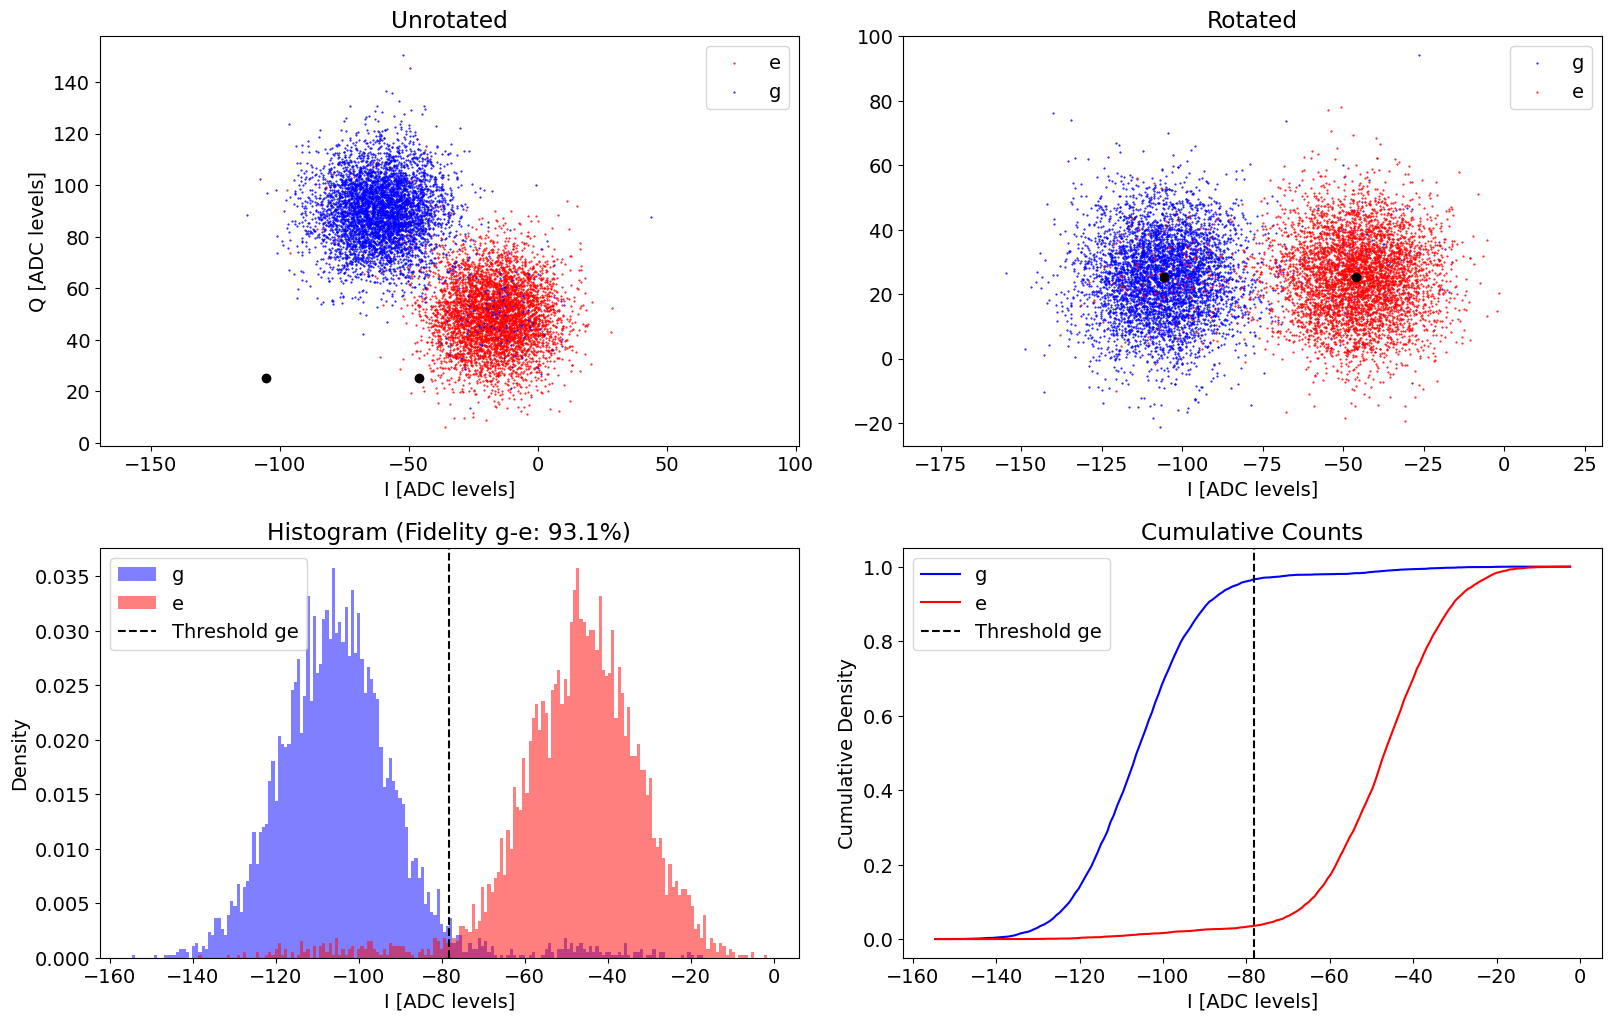

In [34]:
# Execute
# =================================
ss_runner = CharacterizationRunner(
    station = station,
    ExptClass = meas.HistogramExperiment,
    default_expt_cfg = singleshot_defaults,
    postprocessor = singleshot_postproc,
    job_client=client,
)

if expts_to_run['single_shot']:
    ss = ss_runner.execute(
        check_f=False,
        # active_reset=False, # on recalibration of readout, turn off active reset because it will be wrong for selecting when to apply the qubit pulse
        relax_delay=2000,


        reps=5000,
        # active_reset=True,
        # relax_delay=200,
    )
    # ss.display(station)

## Qubit ge

### Pulse-probe

In [35]:
# Define defaults, smart config preprocessing and post-measurement updates
# =====================================
gespec_defaults = AttrDict(dict(    
    # start=center-span/2,  # [MHz]
    # step=span/expts,  # min step ~1 MHz
    expts=200,  # Number of experiments stepping from start
    reps=100,  # Number of averages per point
    rounds=1,  # Number of start to finish sweeps to average over
    length=1,  # Qubit probe constant pulse length [us]
    gain=100,  # Qubit pulse gain
    sigma=0.1,  # Qubit flat top sigma
    qubit=[0],
    qubits=[0],
    prepulse=False,
    pre_sweep_pulse=[],
    gate_based=False,
    relax_delay=250,  # Wait time between experiments [us]
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values


def gespec_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)

    span = kwargs.pop('span', 10)  # MHz
    center = kwargs.pop('center', station.hardware_cfg.device.qubit.f_ge[0])
    expts = kwargs.pop('expts', default_expt_cfg.expts)

    expt_cfg.start = center - span / 2
    expt_cfg.step = span / expts
    
    expt_cfg.update(kwargs)
    return expt_cfg

def gespec_postproc(station, expt):
    old_freq = station.hardware_cfg.device.qubit.f_ge[0]
    station.hardware_cfg.device.qubit.f_ge = [expt.data['fit_avgi'][2]]
    print(f'Updated qubit frequency from {old_freq} to {station.hardware_cfg.device.qubit.f_ge[0]}!')
    station.snapshot_hardware_config(update_main=False)

In [36]:
# Execute
# =================================
gespec_runner = CharacterizationRunner(
    station = station,
    ExptClass = meas.PulseProbeSpectroscopyExperiment,
    default_expt_cfg = gespec_defaults,
    preprocessor = gespec_preproc,
    postprocessor = gespec_postproc,
    job_client=client,
)

if expts_to_run['pulse_probe_ge']:
    gespec = gespec_runner.execute(
        # coupler_current=coupler_current,
    )
    gespec.display()

### T2 Ramsey

In [37]:
# Define defaults, smart config preprocessing and post-measurement updates
# =====================================
from sqlalchemy import false


geramsey_defaults = AttrDict(dict(
    ramsey_freq=0.2,  # [MHz]
    start=0.01, # us
    step=0.5,
    expts=101,
    reps=200,
    rounds=1,
    pre_sweep_pulse=None,
    post_sweep_pulse=None,
    if_ef=False,
    ef_init=True, # redundant
    qubits=[0],
    user_defined_freq=[False, 3568.2038290468167, 5304, 0.035],
    f0g1_cavity=0,
    normalize=False,
    active_reset=False,
    man_reset=False,
    storage_reset=False,
    prepulse=None,
    postpulse=None,
    pre_active_reset_pulse=False,
    gate_based=False,
    advance_phase=0,
    echoes=[False, 0],
    relax_delay=200
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

def geramsey_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)

    # Copied over but what's all this below????
    # Which ones are actually used? 
    # Can we straighten out all the nested boolean logic???
    checkEF = False
    qubit_ge_init = False
    qubit_ge_after = False
    if expt_cfg.if_ef:
        checkEF = True
        qubit_ge_init = True if expt_cfg.ef_init else False
        qubit_ge_after = True if expt_cfg.ef_init else False
    expt_cfg.checkEF = checkEF
    expt_cfg.qubit_ge_init = qubit_ge_init
    expt_cfg.qubit_ge_after = qubit_ge_after

    expt_cfg.prepulse = False if expt_cfg.pre_sweep_pulse is None else True if expt_cfg.prepulse is None else expt_cfg.prepulse,
    expt_cfg.postpulse = False if expt_cfg.post_sweep_pulse is None else True if expt_cfg.postpulse is None else expt_cfg.postpulse,
    
    return expt_cfg

def geramsey_postproc(station, expt):
    old_freq = station.hardware_cfg.device.qubit.f_ge[0]
    station.hardware_cfg.device.qubit.f_ge = [
        station.hardware_cfg.device.qubit.f_ge[0] + min(expt.data['f_adjust_ramsey_avgi'])
    ]
    print(f'Updated qubit frequency from {old_freq} to {station.hardware_cfg.device.qubit.f_ge[0]}!')
    station.snapshot_hardware_config(update_main=False)

In [38]:
# Execute
# =================================
geramsey_runner = CharacterizationRunner(
    station = station,
    ExptClass = meas.RamseyExperiment,
    default_expt_cfg = geramsey_defaults,
    preprocessor = geramsey_preproc,
    postprocessor = geramsey_postproc,
    job_client=client,
)

if expts_to_run['t2_ge']:
    geramsey = geramsey_runner.execute(
        ramsey_freq = 0.2, #0.2
        step=0.4, #0.4
        active_reset=False,
        relax_delay=2500,
        postprocess=True,
        if_ef=False,
    )
    geramsey.display()

### Amplitude Rabi

We should probably use a cosine fit with fixed phase=0 instead of decaying sine with varying phase?

In [39]:
# Define defaults, smart config preprocessing and post-measurement updates
# =====================================
amprabi_defaults = AttrDict(dict(
    start=0,
    step=60,
    expts=151,
    reps=200,
    rounds=1,
    sigma_test=None,
    qubit=0,
    pulse_type='gauss',
    drag_beta=0.0,
    pulse_ge_init=False,
    pulse_ge_after=False,
    checkZZ=False,
    checkEF=False,
    qubits=[0],
    flat_length=0,
    normalize=False,
    single_shot=False,
    singleshot_reps=10000,
    span=50,
    user_defined_freq=[False, 3568.203829046816],
    prepulse=False,
    postpulse=False, 
    if_ef=False,  # If true, will check ef frequency and update it
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

def amprabi_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)

    # Copied over but what's all this below????
    # Which ones are actually used? 
    # Can we straighten out all the nested boolean logic???
    pulse_ge = station.hardware_cfg.device.qubit.pulses.pi_ge
    if expt_cfg.sigma_test is None:
        expt_cfg.sigma_test = pulse_ge.sigma[0]
    if expt_cfg.step is None:
        expt_cfg.step = int(pulse_ge.gain[0] / (expt_cfg.expts - 1))
    
    expt_cfg.checkEF = False
    expt_cfg.pulse_ge_init = False
    expt_cfg.pulse_ge_after = False
    if expt_cfg.if_ef:
        expt_cfg.checkEF = True
        expt_cfg.pulse_ge_init = True
        expt_cfg.pulse_ge_after = True
    
    return expt_cfg

def amprabi_postproc(station, expt):
    station.hardware_cfg.device.qubit.pulses.pi_ge.gain = [expt.data['pi_gain_avgi']]
    station.hardware_cfg.device.qubit.pulses.hpi_ge.gain = [expt.data['hpi_gain_avgi']]
    print('Updated qubit ge pi and hpi gaussian gain!')
    station.snapshot_hardware_config(update_main=False)

In [40]:
# Execute
# =================================
amprabi_runner = CharacterizationRunner(
    station = station,
    ExptClass = meas.AmplitudeRabiExperiment,
    default_expt_cfg = amprabi_defaults,
    preprocessor = amprabi_preproc,
    postprocessor = amprabi_postproc,
    job_client=client,
)

if expts_to_run['amplitude_ge']:
    amprabi = amprabi_runner.execute(
        relax_delay=2500,
        expts=301,
        postprocess=True,
    )
    amprabi.display()

    t2_ramsey_ge_after_amp = geramsey_runner.execute(
        ramsey_freq = 0.2, #0.2,
        step = 0.4, #0.4,
        active_reset = True,
        relax_delay=250,
    )
    t2_ramsey_ge_after_amp.display()


### Error Amplification

In [41]:
# Error Amplification - Runner Pattern with CharacterizationRunner
# =====================================
error_amp_defaults = AttrDict(dict(
    reps=100,
    rounds=1,
    qubit=0,
    n_pulses=10,
    active_reset=False,
    man_reset=True,
    storage_reset=True,
    relax_delay=2500,
    start=0,
    expts=10,
    step=100,
    parameter_to_test='gain',  # 'gain' or 'frequency'
    pulse_type=['qubit', 'ge', 'pi', 0],
    # Multiphoton-specific parameters
    man_no=1,  # Manipulate mode number
    pulse_name='pi',  # 'pi' or 'hpi'
))


def error_amp_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    
    expt_cfg.qubits = [expt_cfg.qubit]
    
    return expt_cfg

def error_amp_postproc(station, expt, state_fin='g'):
    """Update config based on error amplification results.
    
    For multiphoton transitions, updates the multiphoton config.
    For standard qubit calibration, updates the qubit pulse params.
    """
    expt_cfg = expt.cfg.expt
    parameter = expt_cfg.parameter_to_test
    pulse_name = expt_cfg.pulse_type[2]  # 'pi' or 'hpi'
    transition_key = expt_cfg.pulse_type[1] # 'ge' or 'ef'
    print(f'Processing error amplification for parameter: {parameter}, pulse: {pulse_name}')


    if state_fin == 'e':
        expt.analyze(data=expt.data, state_fin='e')
        expt.display(data=expt.data, state_fin='e')

    
    # Get the optimal value from the experiment data
    # Error amplification typically finds the value that minimizes error
    if 'optimal_value' in expt.data:
        optimal_val = expt.data['optimal_value']

    if 'fit_avgi' in expt.data:
        print('parameter:', parameter)
        if parameter == 'frequency':
            optimal_val = expt.data['fit_avgi'][2]
        elif parameter == 'gain':
            optimal_val = int(expt.data['fit_avgi'][2])
        else: 
            raise ValueError(f"Unknown parameter to test: {parameter}")

    else:
        # If no automatic extraction, user needs to analyze manually
        print('No automatic optimal value extraction. Please analyze the data manually.')
        return
    
    # Standard qubit update
    pulse_key = f'{pulse_name}_{transition_key}'
    freq_key = f"f_{transition_key}"
    if parameter == 'frequency':
        old_val = station.hardware_cfg.device.qubit[freq_key][0]
        station.hardware_cfg.device.qubit[freq_key][0] = optimal_val
        print(f'Updated qubit {freq_key} {parameter}: {old_val} -> {optimal_val}')
    elif parameter == 'gain':
        old_val = station.hardware_cfg.device.qubit.pulses[pulse_key]['gain'][0]
        station.hardware_cfg.device.qubit.pulses[pulse_key]['gain'][0] = optimal_val
        print(f'Updated qubit {pulse_key} {parameter}: {old_val} -> {optimal_val}')
        
error_amp_runner_qubit = CharacterizationRunner(
    station=station,
    ExptClass=meas.ErrorAmplificationExperiment,
    default_expt_cfg=error_amp_defaults,
    preprocessor=error_amp_preproc,
    postprocessor=error_amp_postproc,
    job_client=client,
    use_queue=True,
)

Frequency start: 3565.5921559944054, Step: 0.04
Job submitted: JOB-20260909-00046 (queue position: 1)

[6.7s] Job JOB-20260909-00046: running
[WORKER] Loading ErrorAmplificationExperiment from experiments.single_qubit.error_amplification
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260909-00046_ErrorAmplificationExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 90%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊              | 9/10 [00:57<00:06,  6.36s/it]
[70.8s] Job JOB-20260909-00046: completed
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [01:03<00:00,  6.36s/it]
Saving C:\experiments\260701_Calibration\data\JOB-20260909-00046_ErrorAmplificationExperiment.h5
[WOR

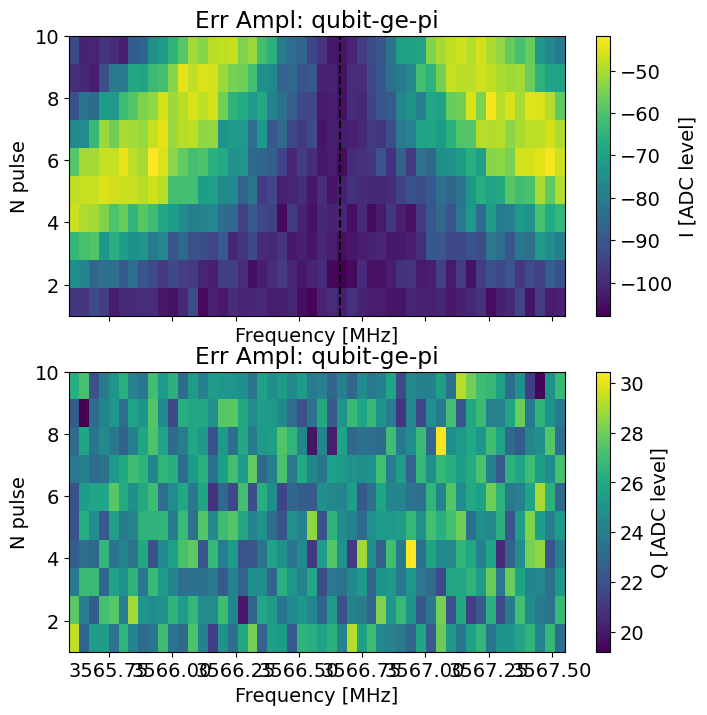

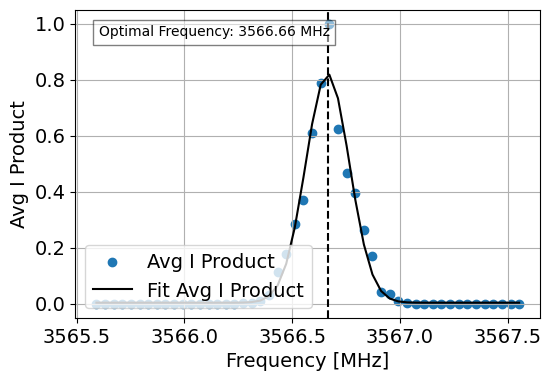

In [42]:
expts = 50 #50
band = 1 #2
freq_start = station.hardware_cfg.device.qubit['f_ge'][0] - band
step = 2 * band / expts
print(f'Frequency start: {freq_start}, Step: {step}')


if expts_to_run['ge_freq_error_amplification']:
    error_amp = error_amp_runner_qubit.execute(
        parameter_to_test='frequency',
        step=2 * band / expts, 
        start=freq_start,
        expts=expts,
        reps=50,
        pulse_type=['qubit', 'ge', 'pi', 0],
        # n_pulses=20,
    )


Gain start: 9077, Step: 40.0
Job submitted: JOB-20260909-00047 (queue position: 1)

[4.6s] Job JOB-20260909-00047: running
[WORKER] Loading ErrorAmplificationExperiment from experiments.single_qubit.error_amplification
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260909-00047_ErrorAmplificationExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 90%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊              | 9/10 [00:29<00:03,  3.23s/it]
[35.3s] Job JOB-20260909-00047: completed
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:32<00:00,  3.23s/it]
Saving C:\experiments\260701_Calibration\data\JOB-20260909-00047_ErrorAmplificationExperiment.h5
[WORKER] Saving expt ob

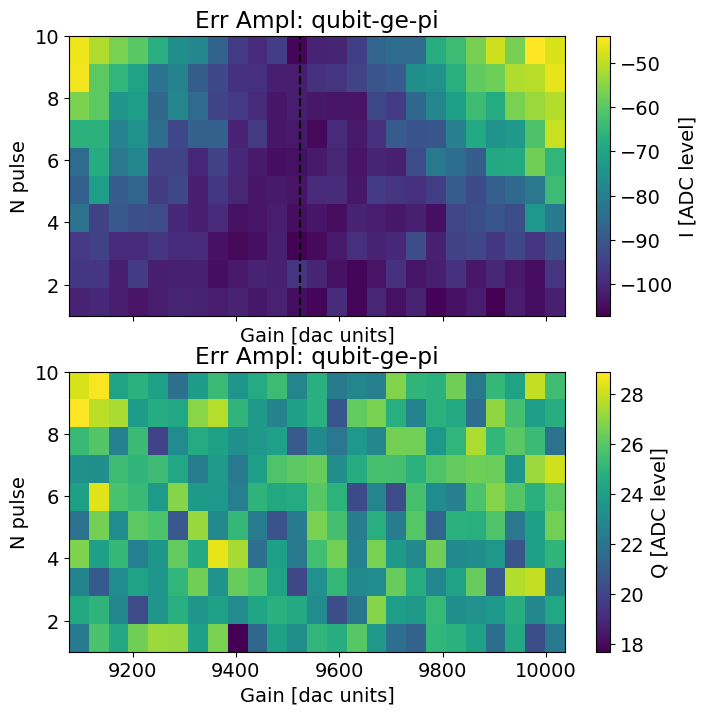

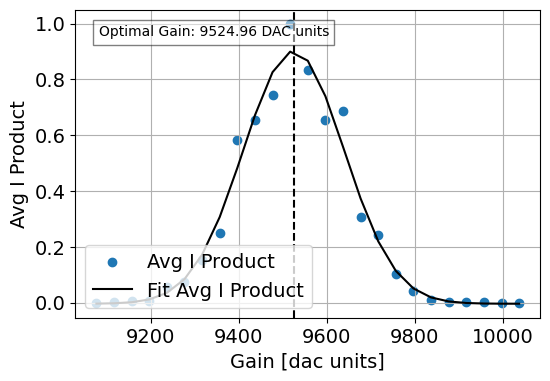

In [43]:
band = 500
expts = 25
gain_start = station.hardware_cfg.device.qubit.pulses.pi_ge.gain[0] - band
step = 2 * band / expts
print(f'Gain start: {gain_start}, Step: {step}')

if expts_to_run['ge_gain_error_amplification']:
    error_amp = error_amp_runner_qubit.execute(
        parameter_to_test='gain',
        step=step,
        start=gain_start,
        expts=expts,
        reps=50,
        pulse_type=['qubit', 'ge', 'pi', 0],
    )

### T1

In [44]:
# Define defaults, smart config preprocessing and post-measurement updates
# =====================================
t1_ge_defaults = AttrDict(dict(
    start=0,
    step=20,
    expts=100,
    reps=100,
    rounds=1,
    qubit=0,
    qubit_ef=False,
    normalize=False,
    relax_delay=2500,
))

def t1_ge_postproc(station, expt):
    station.hardware_cfg.device.qubit.T1 = [expt.data['fit_avgi'][3]]
    print('Updated qubit T1!')
    station.snapshot_hardware_config(update_main=False)


In [45]:
# Execute
# =================================
t1_ge_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.single_qubit.t1.T1Experiment,
    default_expt_cfg=t1_ge_defaults,
    postprocessor=t1_ge_postproc,
    job_client=client,
)

if expts_to_run['t1_ge']:
    t1_ge = t1_ge_runner.execute()
    t1_ge.display()

In [46]:
station.preview_config_update()
# station.snapshot_hardware_config(update_main=True)

Comparing configurations:
Parent config file: C:\python\multimode_expts\configs\versions\hardware_config\CFG-HW-20260905-00001.yml
Key 'device.qubit.f_ge' differs:
  Old value (config1): [3566.5921559944054]
  New value (config2): [3566.6638074853336]
Key 'device.qubit.pulses.pi_ge.gain' differs:
  Old value (config1): [9577]
  New value (config2): [9524]
Key 'device.readout.phase' differs:
  Old value (config1): [509.20853949819633]
  New value (config2): [551.4976132503425]
Key 'device.readout.threshold' differs:
  Old value (config1): [-33.39325445376234]
  New value (config2): [-78.13917399089458]
Key 'device.readout.threshold_list' differs:
  Old value (config1): [[-33.39325445376234]]
  New value (config2): [[-78.13917399089458]]
Key 'device.readout.confusion_matrix_without_reset' differs:
  Old value (config1): [0.9651999999999998, 0.034800000000000164, 0.03840000000000003, 0.9616]
  New value (config2): [0.9661999999999998, 0.03380000000000016, 0.035607121424284856, 0.964392878

## Qubit ef

### Pulse-probe

In [47]:
# Define defaults, smart config preprocessing and post-measurement updates
# =====================================
efspec_defaults = AttrDict(dict(
    start=3415,
    step=0.05,
    expts=500,
    reps=200,
    rounds=1,
    length=1,
    gain=100,
    qubit_f=False,
    qubit=0,
    cavity_drive=False,
    wait_qubit=False,
    relax_delay=500,
))

def efspec_postproc(station, expt):
    old_freq = station.hardware_cfg.device.qubit.f_ef[0]
    station.hardware_cfg.device.qubit.f_ef = [expt.data['fit_avgi'][2]]
    print(f'Updated qubit ef frequency from {old_freq} to {station.hardware_cfg.device.qubit.f_ef[0]}!')
    station.snapshot_hardware_config(update_main=False)

In [48]:
# Execute
# =================================
efspec_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.PulseProbeEFSpectroscopyExperiment,
    default_expt_cfg=efspec_defaults,
    postprocessor=efspec_postproc,
    job_client=client,
)

if expts_to_run['pulse_probe_ef']:
    qspec_ef = efspec_runner.execute(
    expts=500)
    qspec_ef.display()

### T2 Ramsey

In [49]:
# Define defaults, smart config preprocessing and post-measurement updates
# =====================================
# Reuse ge defaults but with if_ef=True
eframsey_defaults = AttrDict(deepcopy(geramsey_defaults))
eframsey_defaults.if_ef = True
eframsey_defaults.ef_init = True
eframsey_defaults.ramsey_freq = 3  # Typical ef ramsey frequency

def eframsey_postproc(station, expt):
    old_freq = station.hardware_cfg.device.qubit.f_ef[0]
    station.hardware_cfg.device.qubit.f_ef = [
        station.hardware_cfg.device.qubit.f_ef[0] + min(expt.data['f_adjust_ramsey_avgi'])
    ]
    print(f'Updated qubit ef frequency from {old_freq} to {station.hardware_cfg.device.qubit.f_ef[0]}!')
    station.snapshot_hardware_config(update_main=False)

In [50]:
# Execute
# =================================
eframsey_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.RamseyExperiment,
    default_expt_cfg=eframsey_defaults,
    preprocessor=geramsey_preproc,  # Reuse ge preprocessor
    postprocessor=eframsey_postproc,
    job_client=client,
)

if expts_to_run['t2_ef']:
    t2ramsey_ef = eframsey_runner.execute(
        ramsey_freq=0.2,
        step = 0.2,
        relax_delay=2500,
        active_reset=True,
    )
    t2ramsey_ef.display()

### Amplitude Rabi

We should probably use a cosine fit with fixed phase=0 instead of decaying sine with varying phase?

In [51]:
# Define defaults, smart config preprocessing and post-measurement updates
# =====================================
# Reuse ge defaults but with if_ef=True
efamprabi_defaults = AttrDict(deepcopy(amprabi_defaults))
efamprabi_defaults.if_ef = True
efamprabi_defaults.step = 40  # Typical ef amplitude step
efamprabi_defaults.expts = 150

def efamprabi_postproc(station, expt):
    station.hardware_cfg.device.qubit.pulses.pi_ef.gain = [expt.data['pi_gain_avgi']]
    station.hardware_cfg.device.qubit.pulses.hpi_ef.gain = [expt.data['hpi_gain_avgi']]
    print('Updated qubit ef pi and hpi gaussian gain!')
    station.snapshot_hardware_config(update_main=False)

In [52]:
# Execute
# =================================
efamprabi_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.AmplitudeRabiExperiment,
    default_expt_cfg=efamprabi_defaults,
    preprocessor=amprabi_preproc,  # Reuse ge preprocessor
    postprocessor=efamprabi_postproc,
    job_client=client,
)

if expts_to_run['amplitude_ef']:
    amprabi_ef = efamprabi_runner.execute(
                relax_delay=2500,
                expts = 500
    )           
    amprabi_ef.display()
    
    # After amplitude calibration, do another T2 Ramsey to fine tune frequency
    t2_ramsey_ef_after_amp = eframsey_runner.execute(
        ramsey_freq=0.5,
        step = 0.1,
        relax_delay=2500,
    )
    t2_ramsey_ef_after_amp.display()

### Error Amplification

In [53]:
# Error Amplification - Runner Pattern with CharacterizationRunner
# =====================================
error_amp_defaults = AttrDict(dict(
    reps=100,
    rounds=1,
    qubit=0,
    n_pulses=10,
    active_reset=False,
    man_reset=True,
    storage_reset=True,
    relax_delay=2500,
    start=0,
    expts=10,
    step=100,
    parameter_to_test='gain',  # 'gain' or 'frequency'
    pulse_type=['qubit', 'ge', 'pi', 0],
    # Multiphoton-specific parameters
    man_no=1,  # Manipulate mode number
    pulse_name='pi',  # 'pi' or 'hpi'
))


def error_amp_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    
    expt_cfg.qubits = [expt_cfg.qubit]
    
    return expt_cfg

def error_amp_postproc(station, expt, state_fin='g'):
    """Update config based on error amplification results.
    
    For multiphoton transitions, updates the multiphoton config.
    For standard qubit calibration, updates the qubit pulse params.
    """
    expt_cfg = expt.cfg.expt
    parameter = expt_cfg.parameter_to_test
    pulse_name = expt_cfg.pulse_type[2]  # 'pi' or 'hpi'
    transition_key = expt_cfg.pulse_type[1] # 'ge' or 'ef'
    print(f'Processing error amplification for parameter: {parameter}, pulse: {pulse_name}')


    if state_fin == 'e':
        expt.analyze(data=expt.data, state_fin='e')
        expt.display(data=expt.data, state_fin='e')

    
    # Get the optimal value from the experiment data
    # Error amplification typically finds the value that minimizes error
    if 'optimal_value' in expt.data:
        optimal_val = expt.data['optimal_value']

    if 'fit_avgi' in expt.data:
        print('parameter:', parameter)
        if parameter == 'frequency':
            optimal_val = expt.data['fit_avgi'][2]
        elif parameter == 'gain':
            optimal_val = int(expt.data['fit_avgi'][2])
        else: 
            raise ValueError(f"Unknown parameter to test: {parameter}")

    else:
        # If no automatic extraction, user needs to analyze manually
        print('No automatic optimal value extraction. Please analyze the data manually.')
        return
    
    # Standard qubit update
    pulse_key = f'{pulse_name}_{transition_key}'
    freq_key = f"f_{transition_key}"
    if parameter == 'frequency':
        old_val = station.hardware_cfg.device.qubit[freq_key][0]
        station.hardware_cfg.device.qubit[freq_key][0] = optimal_val
        print(f'Updated qubit {freq_key} {parameter}: {old_val} -> {optimal_val}')
    elif parameter == 'gain':
        old_val = station.hardware_cfg.device.qubit.pulses[pulse_key]['gain'][0]
        station.hardware_cfg.device.qubit.pulses[pulse_key]['gain'][0] = optimal_val
        print(f'Updated qubit {pulse_key} {parameter}: {old_val} -> {optimal_val}')
        
error_amp_runner_qubit = CharacterizationRunner(
    station=station,
    ExptClass=meas.ErrorAmplificationExperiment,
    default_expt_cfg=error_amp_defaults,
    preprocessor=error_amp_preproc,
    postprocessor=error_amp_postproc,
    job_client=client,
    use_queue=True,
)

Frequency start: 3421.614941921525, Step: 0.04
Job submitted: JOB-20260909-00048 (queue position: 1)

[9.4s] Job JOB-20260909-00048: running
[WORKER] Loading ErrorAmplificationExperiment from experiments.single_qubit.error_amplification
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260909-00048_ErrorAmplificationExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 80%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                            | 8/10 [00:50<00:12,  6.37s/it]
[73.7s] Job JOB-20260909-00048: completed
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [01:03<00:00,  6.37s/it]
Saving C:\experiments\260701_Calibration\data\JOB-20260909-00048_ErrorAmplificationExperiment.h5
[WORK

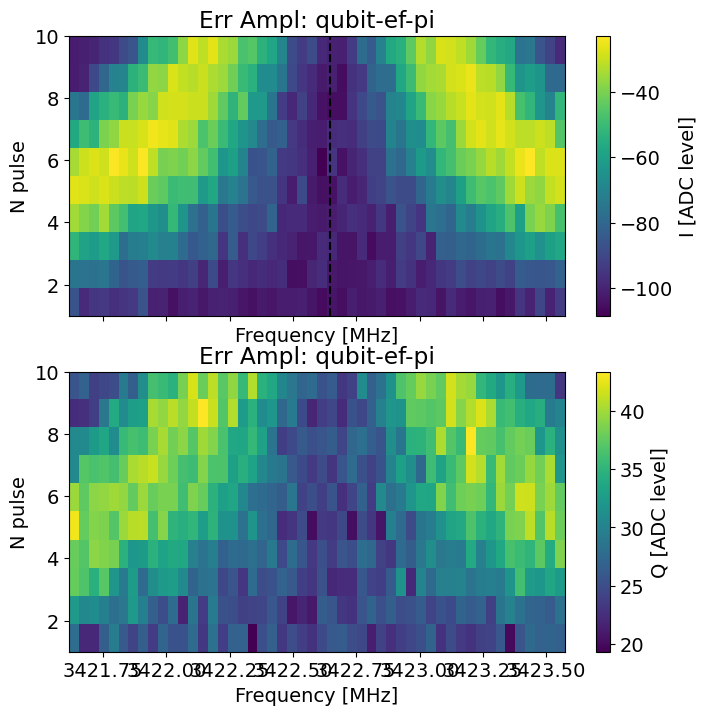

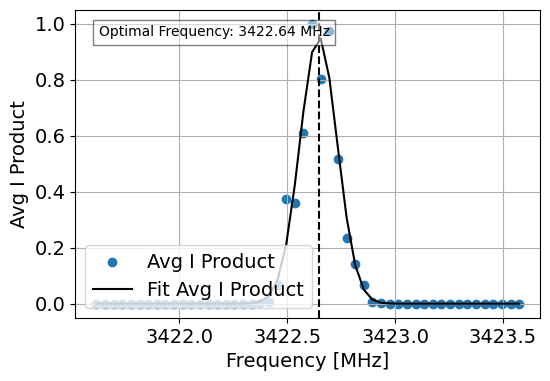

In [54]:
expts = 50 #50
band = 1 #2
freq_start = station.hardware_cfg.device.qubit['f_ef'][0] - band
step = 2 * band / expts
print(f'Frequency start: {freq_start}, Step: {step}')


if expts_to_run['ef_freq_error_amplification']:
    error_amp = error_amp_runner_qubit.execute(
        parameter_to_test='frequency',
        step=2 * band / expts, 
        start=freq_start,
        expts=expts,
        reps=50,
        pulse_type=['qubit', 'ef', 'pi', 0],
        # n_pulses=20,
    )

Gain start: 7134, Step: 40.0
Job submitted: JOB-20260909-00049 (queue position: 1)

[4.4s] Job JOB-20260909-00049: running
[WORKER] Loading ErrorAmplificationExperiment from experiments.single_qubit.error_amplification
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260909-00049_ErrorAmplificationExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:32<00:00,  3.23s/it]
Saving C:\experiments\260701_Calibration\data\JOB-20260909-00049_ErrorAmplificationExperiment.h5
[WORKER] Saving expt object to: C:\experiments\260701_Calibration\expt_objs\JOB-20260909-00049_expt.pkl

[56.8s] Job JOB-20260909-00049: completed

Job completed! Data: C:\experiments\260701_Calibration\data\JOB-20260909-00049_ErrorAmplificatio

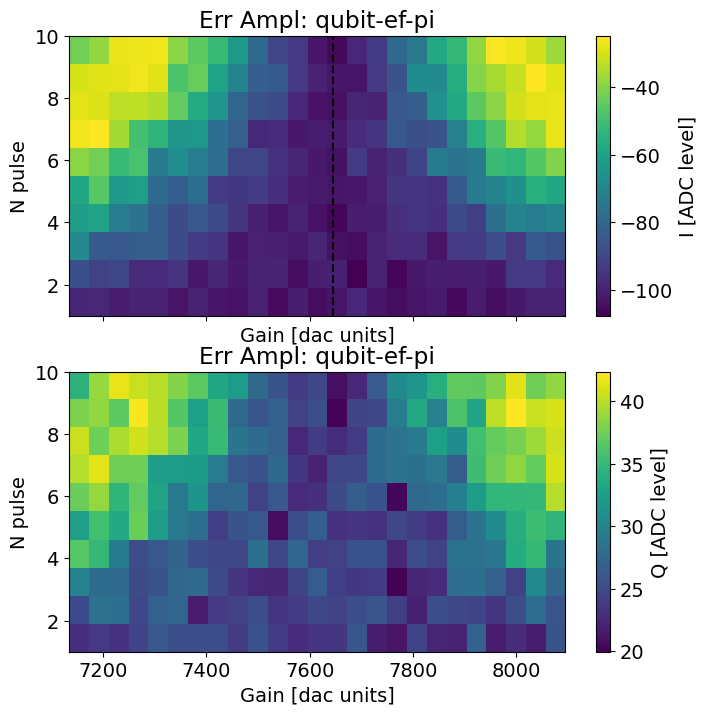

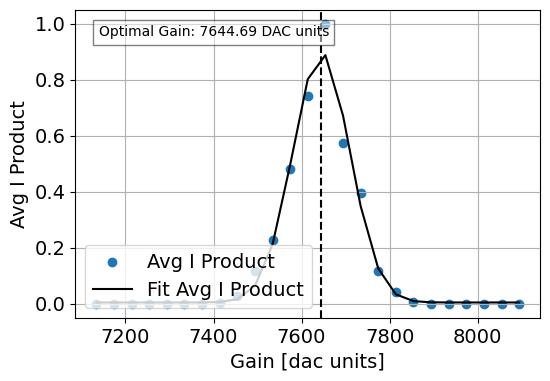

In [55]:
band = 500
expts = 25
gain_start = station.hardware_cfg.device.qubit.pulses.pi_ef.gain[0] - band
step = 2 * band / expts
print(f'Gain start: {gain_start}, Step: {step}')

if expts_to_run['ef_gain_error_amplification']:
    error_amp = error_amp_runner_qubit.execute(
        parameter_to_test='gain',
        step=step,
        start=gain_start,
        expts=expts,
        reps=50,
        pulse_type=['qubit', 'ef', 'pi', 0],
    )

### T1

In [56]:
# Define defaults, smart config preprocessing and post-measurement updates
# =====================================
t1_ef_defaults = AttrDict(dict(
    start=0,
    step=5,
    expts=100,
    reps=50,
    rounds=1,
    qubit=0,
    qubit_ef=True,
    normalize=False,
    relax_delay=2500,
))

def t1_ef_postproc(station, expt):
    station.hardware_cfg.device.qubit.T1_ef = [expt.data['fit_avgq'][3]]
    print('Updated qubit T1 ef!')
    station.snapshot_hardware_config(update_main=False)

In [57]:
# Execute
# =================================
t1_ef_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.T1Experiment,
    default_expt_cfg=t1_ef_defaults,
    postprocessor=t1_ef_postproc,
    job_client=client,
)

if expts_to_run['t1_ef']:
    t1_ef = t1_ef_runner.execute()
    t1_ef.display()

# Manipulate

## Spectroscopy

In [92]:
f0g1spec_defaults = AttrDict(dict(
    start=None,  # Will be computed in preprocessor from ds_storage
    step=0.2,
    expts=200,
    reps=100,
    rounds=1,
    length=1,
    gain=3000,
    pulse_type='gaussian',
    qubit_f=True,
    qubits=[0],
    prepulse=False,
    relax_delay=200,
))

def f0g1spec_preproc(station, default_expt_cfg, man_mode_no=1, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.man_mode_no = man_mode_no  # Store for postprocessor
    expt_cfg.update(kwargs)
    
    # Compute start frequency from dataset if not provided
    if expt_cfg.start is None:
        expt_cfg.start = station.ds_storage.get_freq('M' + str(man_mode_no)) - 20
    
    return expt_cfg

def f0g1spec_postproc(station, expt):
    man_mode_no = expt.cfg.expt.man_mode_no
    station.ds_storage.update_freq('M' + str(man_mode_no), expt.data['fit_avgi'][2])
    station.hardware_cfg.device.multiphoton['pi']['fn-gn+1']['frequency'][0] = expt.data['fit_avgi'][2]
    print(f"Updated man f0g1 freq to: {station.ds_storage.get_freq('M' + str(man_mode_no))}")
    station.snapshot_hardware_config(update_main=False)
    station.snapshot_man1_storage_swap(update_main=False)

In [93]:
# station.yoko_coupler.ramp_current(0.5e-3, sweeprate=0.0001)

In [94]:
# Execute
# =================================
f0g1spec_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.PulseProbeF0g1SpectroscopyExperiment,
    default_expt_cfg=f0g1spec_defaults,
    preprocessor=f0g1spec_preproc,
    postprocessor=f0g1spec_postproc,
    job_client=client,
)

man_specs = [None] * len(expts_to_run['man_modes'])

for i in range(len(expts_to_run['man_modes'])):
    if expts_to_run['pulse_probe_f0g1']:
        print(f'Running pulse probe f0g1 for mode {i+1}')
        man_specs[i] = f0g1spec_runner.execute(
            man_mode_no=i+1,
            go_kwargs=dict(progress=True),
            relax_delay=2500,
            start = 1980
        )
        # man_specs[i].display()


## Find Frequency (Chevron)


In [95]:
chevron_defaults = AttrDict(dict(
    start=0, # time start in us
    step=0.1, # time step in us
    expts=25, # number of time points
    reps=100,
    rounds=1,
    qubits=[0],
    gain=None, # Leave as None to use current value in dataset
    ramp_sigma=0.005,
    use_arb_waveform=False,
    pi_ge_before=True,
    pi_ef_before=True,
    pi_ge_after=False,
    normalize=False,
    active_reset=False,
    check_man_reset=[False, 0],
    check_man_reset_pi=[],
    prepulse=False,
    pre_sweep_pulse=[],
    err_amp_reps=0,
    swap_lossy=False,
))


def f0g1_chevron_postproc(station, mother_expt):
    expt_cfg = mother_expt.cfg.expt
    expt_cfg.man_mode_no = 1
    stor_name = f'M{expt_cfg.man_mode_no}'

    from fitting.fit_display_classes import ChevronFitting

    chevron_analysis = ChevronFitting(
        frequencies=mother_expt.data['freq_sweep'],
        time=mother_expt.data['xpts'][0],
        response_matrix=mother_expt.data['avgi'],
        config=station.hardware_cfg,
        station=station,
    )

    chevron_analysis.analyze()
    
    best_freq = chevron_analysis.results.get('best_frequency_contrast')
        
    if best_freq:
        print(f"Best frequency found: {best_freq:.4f} MHz")
        station.ds_storage.update_freq(stor_name, best_freq)
        station.hardware_cfg.device.multiphoton['pi']['fn-gn+1']['frequency'][0] = best_freq
        print(f"Updated {stor_name} frequency to {best_freq:.4f} MHz (ds_storage and hardware_cfg)")

        pi_len = abs(np.pi / chevron_analysis.results['best_fit_params_period']['omega'])
        station.ds_storage.update_pi(stor_name, pi_len)
        station.hardware_cfg.device.multiphoton['pi']['fn-gn+1']['length'][0] = pi_len
        print('Updated the pi length to:', pi_len, "(ds_storage and hardware_cfg)")

        station.ds_storage.update_h_pi(stor_name, pi_len / 2)
        print('Updated the h_pi length to:', pi_len / 2, "(ds_storage)")

        gain = expt_cfg.get('gain', station.ds_storage.get_gain(stor_name))
        station.ds_storage.update_gain(stor_name, gain)
        station.hardware_cfg.device.multiphoton['pi']['fn-gn+1']['gain'][0] = gain
        print('Updated gain to:', gain)
    mother_expt.analysis = chevron_analysis
    chevron_analysis.display_results()
    station.snapshot_man1_storage_swap(update_main=False)
    station.snapshot_hardware_config(update_main=False)


runner = SweepRunner(
    station=station,
    ExptClass=meas.LengthRabiGeneralF0g1Experiment,
    default_expt_cfg=chevron_defaults,
    sweep_param='freq',
    live_plot=False,
    # preprocessor=my_preproc,
    postprocessor=f0g1_chevron_postproc,
    job_client=client,
)

In [96]:
# coarse sweep
if expts_to_run["man_freq_coarse_chevron"]:
    f0g1_chevron = runner.execute(
        sweep_start=station.ds_storage.get_freq('M1') - 3,
        sweep_stop=station.ds_storage.get_freq('M1') + 3,
        sweep_npts=11,
        gain = station.ds_storage.get_gain('M1'),
        start = 1, # time start in us
        batch=True,
    )

In [97]:
# fine sweep

if expts_to_run["man_freq_fine_chevron"]:
    f0g1_chevron = runner.execute(
        sweep_start=station.ds_storage.get_freq('M1') - 0.5,
        sweep_stop=station.ds_storage.get_freq('M1') + 0.5,
        sweep_npts=11,
        gain = station.ds_storage.get_gain('M1'),
        # start = 1, # time start in us
        # coupler_current=coupler_current,
        reps=75,
        batch=True,
    )

## Error amplification

Job submitted: JOB-20260909-00060 (queue position: 1)

[7.0s] Job JOB-20260909-00060: pending

[14.0s] Job JOB-20260909-00060: running
[WORKER] Loading ErrorAmplificationExperiment from experiments.single_qubit.error_amplification
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260909-00060_ErrorAmplificationExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [01:11<00:00, 10.15s/it]
Saving C:\experiments\260701_Calibration\data\JOB-20260909-00060_ErrorAmplificationExperiment.h5
[WORKER] Saving expt object to: C:\experiments\260701_Calibration\expt_objs\JOB-20260909-00060_expt.pkl

[101.3s] Job JOB-20260909-00060: completed

Job completed! Data: C:\experiments\260701_Calibration\data\JOB-20260909-00060_Erro

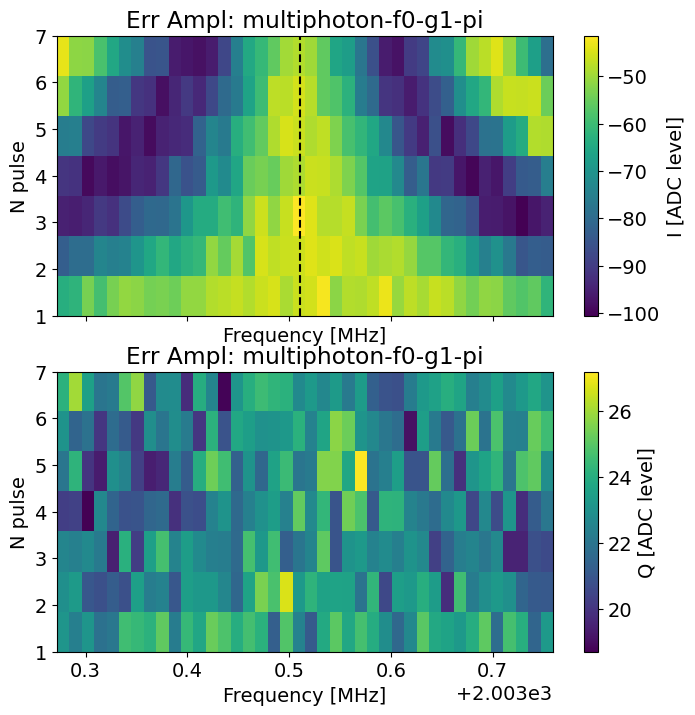

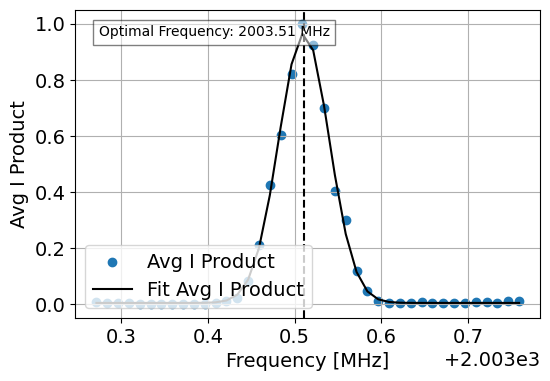

In [98]:
# Manipulate/Error Amplification - New Pattern with CharacterizationRunner
span = 0.5
expts = 40


center_freq = station.ds_storage.get_freq('M1')
start = center_freq - span/2
steps = span/expts


# Configuration defaults
error_amp_defaults = AttrDict(dict(
    start=start,
    expts=expts,
    step=steps, # 0.025
    # start=1984,
    # expts=40,
    # step=0.025, # 0.025
    reps=100,
    rounds=1,
    qubit=0,
    qubits=[0],
    n_pulses=7,
    sideband = 'f0-g1', #should be in the format of 'fn-gn+1' 
    parameter_to_test='frequency',
    pulse_type= None, # if this is None, will be set to ['multiphoton', sideband, 'pi', 0] in preproc
    active_reset=False,
    man_reset=True,
    storage_reset=True,
    relax_delay=2500,
))

def error_amp_preproc(station, 
                      default_expt_cfg, 
                      **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    if expt_cfg.pulse_type is None:
        expt_cfg.pulse_type = ['multiphoton', expt_cfg.sideband, 'pi', 0]
    return expt_cfg

def error_amp_postproc(station, expt):
    """
    Postprocessor for error amplification.
    Analyze with custom parameters.
    """
    sideband = expt.cfg.expt.sideband
    _sideband = sideband[0] + 'n' + '-' + sideband[3] + 'n+1'
    i = int(sideband[1])
    # Perform analysis with state_fin='e' as in original code
    expt.analyze(data=expt.data, state_fin='e')
    # expt.display(data=expt.data, state_fin='e')
    print('Error amplification analysis complete')

    print(f"Man {sideband} pi frequency before update:", 
          station.hardware_cfg.device.multiphoton['pi'][_sideband]['frequency'][i])
    station.hardware_cfg.device.multiphoton['pi'][_sideband]['frequency'][i] = expt.data['fit_avgi'][2]
    print(f"Man {sideband} pi frequency after update:", 
          station.hardware_cfg.device.multiphoton['pi'][_sideband]['frequency'][i])
    if i > 0:
        print("WARNING! No update will occur! The update in this cell was meant for the csv which does not have multiphoton params. To update the multiphoton params, please run the multiphoton calibration notebook instead.")
    else:
        station.ds_storage.update_freq('M1', expt.data['fit_avgi'][2])
        print("Updated the ds_storage frequency to:", station.ds_storage.get_freq('M1'))
    station.snapshot_hardware_config(update_main=False)
    station.snapshot_multiphoton_config(update_main=False)

# Create runner
error_amp_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.ErrorAmplificationExperiment,
    default_expt_cfg=error_amp_defaults,
    preprocessor=error_amp_preproc,
    postprocessor=error_amp_postproc,
    job_client=client,
)

# Example execution

# Run with analyze=False, display=False initially
# Postprocessor will handle custom analysis

if expts_to_run["man_error_amplification"]:
    error_amp_exp = error_amp_runner.execute(
        reps = 100, #100
        go_kwargs = dict(analyze=False, display=False),
        postprocess=True  # This will call postprocessor which does the custom analysis
    )


## Length Rabi f0g1 (Update time)

In [99]:
# Define defaults, smart config preprocessing and post-measurement updates
# =====================================
lenrabi_f0g1_defaults = AttrDict(dict(
    start=None,  # Will be computed in preprocessor (soc.cycles2us(3))
    step=0.01,
    qubits=[0],
    expts=150,
    reps=100,
    rounds=1,
    gain=8000,
    freq=None,  # Will be set from ds_storage in preprocessor
    use_arb_waveform=False,
    pi_ge_before=True,
    pi_ef_before=True,
    pi_ge_after=True,
    normalize=False,
    active_reset=False,
    man_reset=True,
    stor_reset=True,
    check_man_reset=[False, 0],
    swap_lossy=False,
    check_man_reset_pi=[],
    prepulse=False,
    pre_sweep_pulse=[],
    err_amp_reps=0,
    relax_delay=5000,
))

def lenrabi_f0g1_preproc(station, default_expt_cfg, man_mode_no=1, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.man_mode_no = man_mode_no  # Store for postprocessor
    expt_cfg.update(kwargs)
    
    # Compute start and freq from soc and ds_storage if not provided
    if expt_cfg.start is None:
        expt_cfg.start = station.soccfg.cycles2us(3)
    if expt_cfg.freq is None:
        expt_cfg.freq = station.ds_storage.get_freq('M' + str(man_mode_no))
    
    return expt_cfg

# def lenrabi_f0g1_postproc(station, expt):
#     man_mode_no = expt.cfg.expt.man_mode_no
    
#     # Get analysis results from the LengthRabiFitting object stored in expt
#     if hasattr(expt, '_length_rabi_analysis'):
#         analysis = expt._length_rabi_analysis
#         pi_length = analysis.results['pi_length']
#         pi2_length = analysis.results['pi2_length']
#         gain = expt.cfg.expt.gain
#         freq = expt.cfg.expt.freq

       
#         station.ds_storage.update_all('M' + str(man_mode_no), freq, None, pi_length, pi2_length, gain)
#         print(f'Updated dataset M{man_mode_no}: pi_length={pi_length:.4f}, pi2_length={pi2_length:.4f}, gain={gain}')

#         station.snapshot_hardware_config(update_main=False)
#         station.snapshot_multiphoton_config(update_main=False)

def lenrabi_f0g1_postproc(station, expt):
    man_mode_no = expt.cfg.expt.man_mode_no
    
    # Get analysis results from the LengthRabiFitting object stored in expt
    if hasattr(expt, '_length_rabi_analysis'):
        analysis = expt._length_rabi_analysis
        pi_length = analysis.results['pi_length']
        pi2_length = analysis.results['pi2_length']
        gain = expt.cfg.expt.gain
        freq = expt.cfg.expt.freq

        station.ds_storage.update_freq('M' + str(man_mode_no), freq)
        station.ds_storage.update_pi('M' + str(man_mode_no), pi_length)
        station.ds_storage.update_h_pi('M' + str(man_mode_no), pi2_length)
        station.ds_storage.update_gain('M' + str(man_mode_no), gain)
        print(f'Updated dataset M{man_mode_no}: pi_length={pi_length:.4f}, pi2_length={pi2_length:.4f}, gain={gain}')

        station.snapshot_hardware_config(update_main=False)
        station.snapshot_multiphoton_config(update_main=False)

Running length rabi for mode 1
Job submitted: JOB-20260909-00061 (queue position: 1)

[2.3s] Job JOB-20260909-00061: running
[WORKER] Loading LengthRabiGeneralF0g1Experiment from experiments.single_qubit.length_rabi_f0g1_general
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260909-00061_LengthRabiGeneralF0g1Experiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 86%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                   | 129/150 [01:15<00:12,  1.71it/s]
[86.8s] Job JOB-20260909-00061: completed
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [01:27<00:00,  1.71it/s]
Saving C:\experiments\260701_Calibration\data\JOB-20260909-00061_LengthRabiGeneralF0g1Experiment.h5
[WORKER

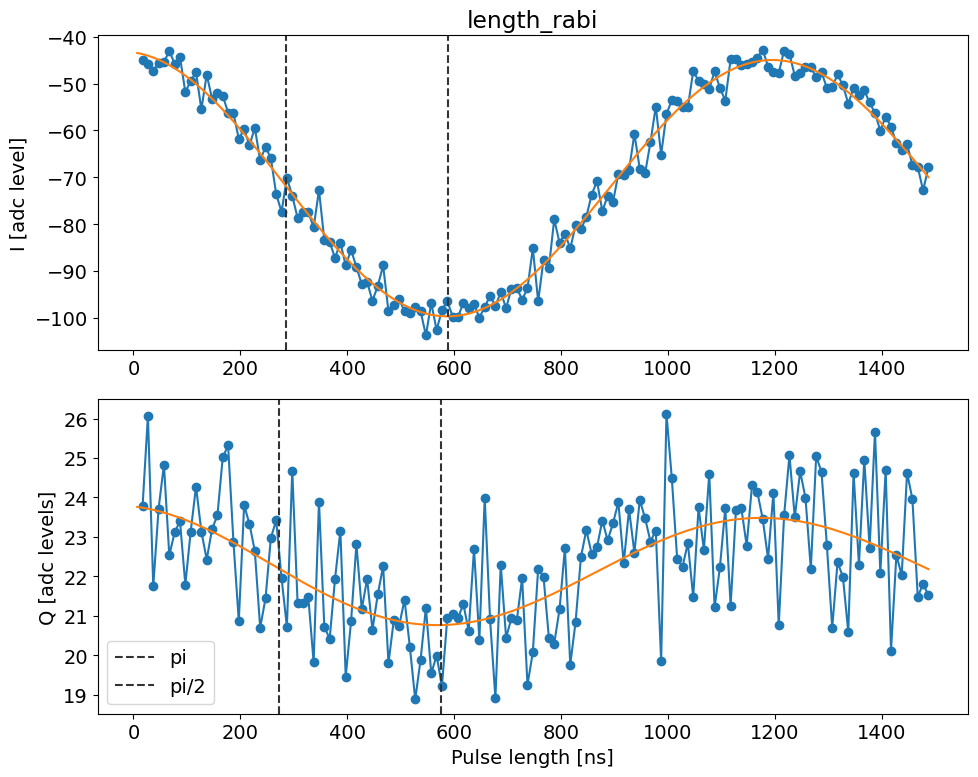

p1: 0.822543451777909
p2: 95.5308605189207
Pi length: 0.5891925800527897
Pi/2 length: 0.2852572688426273
p1: 0.8245760000909926
p2: 99.33759806114081
Pi length: 0.5749163540481763
Pi/2 length: 0.271730231759373


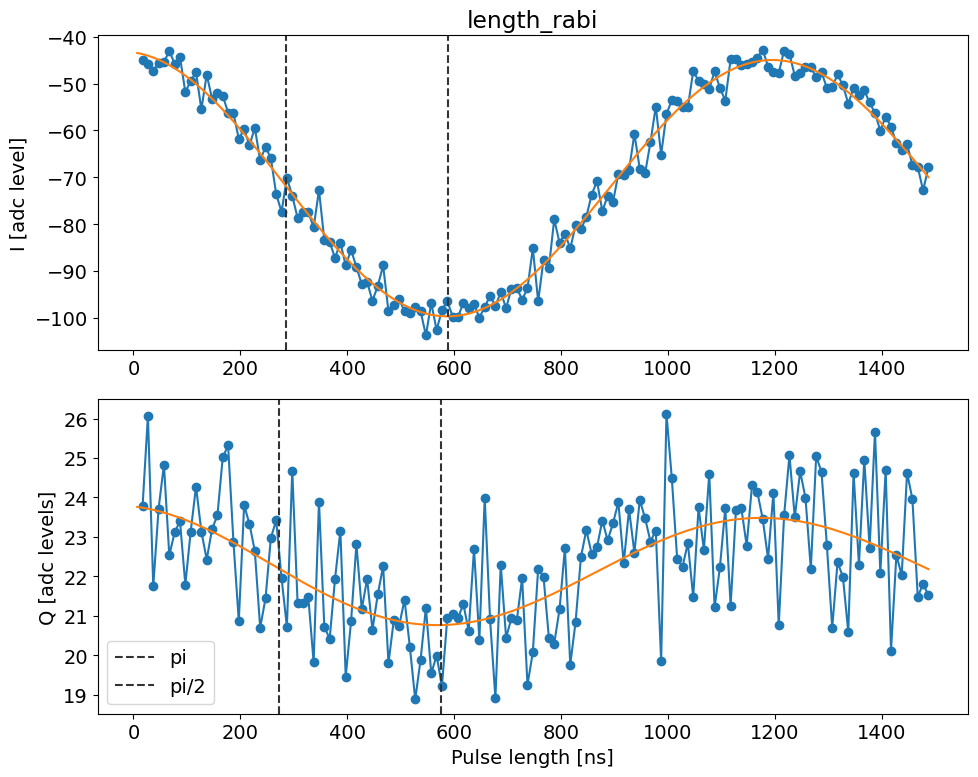

In [100]:
# Execute
# =================================
lenrabi_f0g1_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.LengthRabiGeneralF0g1Experiment,
    default_expt_cfg=lenrabi_f0g1_defaults,
    preprocessor=lenrabi_f0g1_preproc,
    postprocessor=lenrabi_f0g1_postproc,
    job_client=client,
)

len_rabis_mans = [None] * len(expts_to_run['man_modes'])

for i in range(len(expts_to_run['man_modes'])):
    if expts_to_run['length_rabi'] or expts_to_run['length_rabi_sweep']:
        print(f'Running length rabi for mode {i+1}')
        len_rabis_mans[i] = lenrabi_f0g1_runner.execute(
            man_mode_no=i+1,
            go_kwargs=dict(progress=True),
            step=0.01,
        )
        len_rabis_mans[i].display()


## --- Manipulate sections below not refactored ---

## Chi between qubit and Manipulate 

### ge

In [101]:
mm_base_dummy = MM_dual_rail_base(station.hardware_cfg, station.soccfg)
prep_man_pi = mm_base_dummy.prep_man_photon(1)
mm_base_dummy.get_prepulse_creator(prep_man_pi).pulse

array([[3566.020287415535, 3422.7074414111444, 2003.5109901669327],
       [9478, 7712, 8000],
       [0, 0, 0.5728332535504842],
       [0, 0, 0],
       [2, 2, 0],
       ['gauss', 'gauss', 'flat_top'],
       [0.035, 0.035, 0.005]], dtype=object)

In [102]:
from experiments.MM_dual_rail_base import MM_dual_rail_base
import numpy as np
config_thisrun = station.hardware_cfg
# the do function contains 2 calls to ramsey, one with no prepulse and one with prepulse 
# that initializes manipulation mode to 1 state
# do_t2_ramsey_ge is already defined in previous cells and can be used directly

# Add active_reset, relax_delay, expts as arguments and pass them to do_t2_ramsey_ge
def do_chi(config_thisrun, expt_path, config_path, prepulse=None, standard_ramsey=True,
           man_mode_no=1, active_reset=False, relax_delay=2500, expts=100):
    """
    Run two Ramsey experiments: one standard, one with a prepulse that initializes manipulation mode 1.
    Returns both experiment objects.
    """
    # Standard Ramsey (no prepulse)
    if standard_ramsey:
        t2ramsey_no_prepulse = do_t2_ramsey_ge(
            config_thisrun, expt_path, config_path,
            pre_sweep_pulse=None, post_sweep_pulse=None,
            step_size=0.1,
            active_reset=active_reset,
            relax_delay=relax_delay,
            expts=expts
        )
    else: 
        t2ramsey_no_prepulse = None

    # Ramsey with prepulse (initialize manipulation mode 1)
    if prepulse is None:
        mm_base_dummy = MM_dual_rail_base(config_thisrun, soc)
        prep_man_pi = mm_base_dummy.prep_man_photon(man_mode_no)
        prepulse = mm_base_dummy.get_prepulse_creator(prep_man_pi).pulse.tolist()

    t2ramsey_with_prepulse = do_t2_ramsey_ge(
        config_thisrun, expt_path, config_path,
        pre_sweep_pulse=prepulse, post_sweep_pulse=None,
        step_size=0.1,
        active_reset=active_reset,
        relax_delay=relax_delay,
        expts=expts
    )

    return t2ramsey_no_prepulse, t2ramsey_with_prepulse


def update_chi(t2_ramsey_original, t2_ramsey_prepulse, config_thisrun, man_mode_no=1):
    """
    Update config_thisrun.device.qubit.chi for the given manipulation mode.
    """
    f_without_prepulse = t2_ramsey_original.data['f_adjust_ramsey_avgi'][0]
    f_with_prepulse = t2_ramsey_prepulse.data['f_adjust_ramsey_avgi'][0]
    chi = f_with_prepulse - f_without_prepulse
    print('Chi:', chi)
    config_thisrun.device.manipulate.chi_ge[man_mode_no - 1] = chi
    config_thisrun.device.manipulate.revival_time[man_mode_no-1] = np.abs(np.pi/(2 * np.pi * chi))
    print('Delay time (mus):', config_thisrun.device.manipulate.revival_time[man_mode_no-1] )


In [103]:
t2_ramsey_original, t2_ramsey_prepulse = None, None
# Run the chi experiments/__pycache__/
if expts_to_run['chi_ge']:
    t2_ramsey_original, t2_ramsey_prepulse = do_chi(config_thisrun, expt_path, config_path, standard_ramsey=True)
    # analyze and display the results
    t2_ramsey_original.analyze(fitparams=[300, None, None, None, None, None])
    t2_ramsey_original.display()
    t2_ramsey_prepulse.analyze(fitparams=[300, None, None, None, None, None])
    t2_ramsey_prepulse.display() 
    # update the config_thisrun with the chi value
    update_chi(t2_ramsey_original, t2_ramsey_prepulse, config_thisrun, man_mode_no=1)
    print('Only doing it for mode 1')

### ef

In [104]:
from experiments.MM_dual_rail_base import MM_dual_rail_base

# the do function contains 2 calls to ramsey, one with no prepulse and one with prepulse 
# that initializes manipulation mode to 1 state
def do_chi_f(config_thisrun, expt_path, config_path, 
           man_mode_no=1):
    """
    Run two Ramsey experiments: one standard, one with a prepulse that initializes manipulation mode 1.
    Returns both experiment objects.
    """

    
    mm_base_dummy = MM_dual_rail_base(config_thisrun, soc)
    prep_man_pi = mm_base_dummy.prep_man_photon(man_mode_no)
    # Add qubit ge prepulse and postpulse for ef (ge init)
    qubit_ge_prepulse = [['qubit', 'ge', 'pi', 0]]
    prep_man_pi_prepulse = mm_base_dummy.get_prepulse_creator(prep_man_pi).pulse.tolist()
    prepulse =  mm_base_dummy.get_prepulse_creator(prep_man_pi + qubit_ge_prepulse ).pulse.tolist() 
    postpulse  = mm_base_dummy.get_prepulse_creator(qubit_ge_prepulse).pulse.tolist()

    # Add chi to frequency of qubit ge 
    # prepulse[0][-1] += config_thisrun.device.manipulate.chi[man_mode_no - 1]
    # postpulse[0][-1] += config_thisrun.device.manipulate.chi[man_mode_no - 1]

    # Do an ef and ge ramsey with this prepulse 
    # Run ge Ramsey 
    
    
    t2ramsey_no_prepulse_ge = do_t2_ramsey_ge(config_thisrun,
        expt_path,
        config_path,
        step_size=0.1,
        pre_sweep_pulse=prep_man_pi_prepulse,
        post_sweep_pulse=None)
    # Run ef Ramsey with prepulse and postpulse
    t2ramsey_with_prepulse_ef = do_t2_ramsey_ef(
        config_thisrun,
        expt_path,
        config_path,
        pre_sweep_pulse=prepulse,
        post_sweep_pulse=postpulse,
        step_size=0.1,
        ef_init=False  # Do not initialize ef, we are already in ef state
    )
    

    return t2ramsey_no_prepulse_ge, t2ramsey_with_prepulse_ef

def update_chi_ef(t2_standard_ramsey, t2_prepulsed_ramsey, config_thisrun, man_mode_no=1):
    """
    Update config_thisrun.device.qubit.chi for the given manipulation mode.
    """
    f_with_prepulse = t2_prepulsed_ramsey.data['f_adjust_ramsey_avgi'][0]
    f_without_prepulse = t2_standard_ramsey.data['f_adjust_ramsey_avgi'][0]
    chi_ef = f_with_prepulse - f_without_prepulse
    print('Chi:', chi_ef)
    config_thisrun.device.manipulate.chi_ef[man_mode_no - 1] = chi_ef


In [105]:
man_mode_no = 1
t2ge_ramsey_forchief, t2ef_ramsey_forchief = None, None
t2ef_standard_ramsey_forchief = None
if expts_to_run['chi_ef']:
    
    #get standard ef ramsey 
    t2ef_standard_ramsey_forchief = do_t2_ramsey_ef(config_thisrun, expt_path, config_path)
    # analyze and display the results
    t2ef_standard_ramsey_forchief.analyze(fitparams=[300, None, None, None, None, None])
    t2ef_standard_ramsey_forchief.display(title_str='T2_ef_standard_for_chief')

    # Now ramseys with man photon prepulse
    config_thisrun_chief = deepcopy(config_thisrun)
    config_thisrun_chief.device.qubit.f_ge[0] += config_thisrun.device.manipulate.chi_ge[man_mode_no - 1]
    t2ge_ramsey_forchief, t2ef_ramsey_forchief = do_chi_f(config_thisrun_chief, expt_path, config_path)
    # analyze and display the results
    t2ge_ramsey_forchief.analyze(fitparams=[300, None, None, None, None, None])
    t2ge_ramsey_forchief.display(title_str='T2_ge_for_chief_tocheck_this_is_correctly_at_ramsey_freq')
    t2ef_ramsey_forchief.analyze(fitparams=[300, None, None, None, None, None])
    t2ef_ramsey_forchief.display(title_str='T2_ef_for_chief')
    # update the config_thisrun with the chi value
    update_chi_ef(t2ef_standard_ramsey_forchief, t2ef_ramsey_forchief, config_thisrun)


## Parity Delay
NOT Implemented yet: We can use chi to estimate parity waiting time pi/chi but can also fine tune it using this experiment

Basically Length rabi analysis 

In [106]:
parity_delay_defaults = AttrDict(dict(
    start=0.01,
    step=0.05,
    expts=50,
    reps=250,
    rounds=1,
    qubits=[0],
    parity_fast=False,
    normalize=False,
    active_reset=False,
    man_reset=True,
    gate_based=False,
    storage_reset=True,
    man_mode_no=1,
    relax_delay=2500, 
    param_to_calib='length', # length or ac_stark_shift 
    shift_sign=1, # 1 or -1 for ac stark shift direction
    ))

mm_base_calib = MM_dual_rail_base(station.hardware_cfg, station.soccfg)

def parity_delay_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    if 'param_to_calib' in expt_cfg and expt_cfg.param_to_calib =='ac_stark_shift':
        expt_cfg.prepulse = False
        expt_cfg.pre_sweep_pulse = []
    elif 'param_to_calib' in expt_cfg and expt_cfg.param_to_calib =='length':
        expt_cfg.prepulse = True
        pre_sweep_pulse = mm_base_calib.prep_man_photon(man_no=expt_cfg.man_mode_no, photon_no=1)
        pre_sweep_pulse = mm_base_calib.get_prepulse_creator(pre_sweep_pulse, station.hardware_cfg).pulse.tolist()
        expt_cfg.pre_sweep_pulse = pre_sweep_pulse
    return expt_cfg

def parity_delay_postproc(station, expt):
    from fitting.fit_display_classes import LengthRabiFitting
    # Analyze the data
    length_rabi_analysis = LengthRabiFitting(expt.data, config = expt.cfg)
    for key in ['xpts', 'avgi', 'avgq']:
        if key in length_rabi_analysis.data:
            length_rabi_analysis.data[key] = np.array(length_rabi_analysis.data[key])
    length_rabi_analysis.analyze() #fitparams = [100, 0.1, 0, None, None, None])
    length_rabi_analysis.display(title_str='Length Rabi General F0g1')
    expt_cfg = expt.cfg.expt
    man_mode_no = expt_cfg.man_mode_no
    shift_sign = expt_cfg.shift_sign


    if expt_cfg.param_to_calib == 'length':
        delay = length_rabi_analysis.results['pi_length']
        print(f'Fitted revival time: {delay} us')
        old_delay = station.hardware_cfg.device.manipulate.revival_time[man_mode_no - 1]
        station.hardware_cfg.device.manipulate.revival_time[man_mode_no - 1] = delay
        print(f'Updated revival time for mode {man_mode_no}: {old_delay} -> {station.hardware_cfg.device.manipulate.revival_time[man_mode_no - 1]}')

    elif expt_cfg.param_to_calib == 'ac_stark_shift': 
        freq = length_rabi_analysis.data['fit_avgi'][1]
        print(f'Fitted ac Stark shift: {freq} MHz')
        old_freq = station.hardware_cfg.device.manipulate.revival_stark_shift[man_mode_no - 1]
        station.hardware_cfg.device.manipulate.revival_stark_shift[man_mode_no - 1] += shift_sign * freq
        print(f'Updated ac Stark shift for mode {man_mode_no}: {old_freq} -> {station.hardware_cfg.device.manipulate.revival_stark_shift[man_mode_no - 1]}')


### Calibrate first the AC stark shift

Manipulate in 0, qubit should not rotate

this is calibrating the virtual Z to correct from rotating frame to bare frame

In [107]:
parity_delay_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.ParityDelayExperiment,
    default_expt_cfg=parity_delay_defaults,
    postprocessor=parity_delay_postproc,
    preprocessor=parity_delay_preproc,
    job_client=client,
    use_queue=True,
)

if expts_to_run["parity_delay_fast"]:
    parity_delay_ac_stark = parity_delay_runner.execute(
        param_to_calib='ac_stark_shift', 
        go_kwargs=dict(analyze=False, display=False),
        step=0.2,
        expts=100,
        reps=100,
        shift_sign=1,
        # coupler_current=0.0,
    )

Confirming the correction is in the right direction

In [108]:
parity_delay_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.ParityDelayExperiment,
    default_expt_cfg=parity_delay_defaults,
    preprocessor=parity_delay_preproc,
    job_client=client,
    use_queue=True,
)

if expts_to_run["parity_delay_fast"]:
    parity_delay_ac_stark = parity_delay_runner.execute(
        param_to_calib='ac_stark_shift', 
        go_kwargs=dict(analyze=False, display=False),
        step=0.2,
        expts=100,
        reps=100,
        shift_sign=1,
        # coupler_current=0.0,
    )
    parity_delay_ac_stark.display(fit=False)

### Now parity length after the AC stark shift is calibrated

In [109]:
parity_delay_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.ParityDelayExperiment,
    default_expt_cfg=parity_delay_defaults,
    postprocessor=parity_delay_postproc,
    preprocessor=parity_delay_preproc,
    job_client=client,
    use_queue=True,
)

if expts_to_run["parity_delay_fast"] or expts_to_run["parity_delay_slow"]:
    parity_fast = expts_to_run["parity_delay_fast"]
    parity_delay_ac_stark = parity_delay_runner.execute(
        param_to_calib='length', 
        parity_fast=parity_fast,
        go_kwargs=dict(analyze=False, display=False),
        step=0.04,
        expts=100,
        reps=100,
        # coupler_current=0.0,
    )

Job submitted: JOB-20260909-00062 (queue position: 1)

[6.4s] Job JOB-20260909-00062: running
[WORKER] Loading ParityDelayExperiment from experiments.single_qubit.parity_delay
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260909-00062_ParityDelayExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 85%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                     | 85/100 [00:30<00:05,  2.78it/s]
[WORKER] Ctrl+C received, cancelling current job JOB-20260909-00062...
[WORKER] Worker will continue processing queue. Press Ctrl+C again to stop worker.
 85%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                     | 85/100 [00:31<00:05,  2.73it/s]

[55.7s] Job JOB-20260909-00062: failed

Job failed: Job c

RuntimeError: Job JOB-20260909-00062 failed: Job cancelled by user (Ctrl+C)

## T1

In [ ]:
t1_manipulate_defaults = AttrDict(dict(
    start=0,
    step=8,
    expts=120,
    reps=500,
    rounds=1,
    man_mode_no=1,
    f0g1_param=None,
    cavity_prepulse=[False, 300, 1.5],
    f0g1_prep=True,
    resolved_pi=False,
    qubit=0,
    normalize=False,
))


def t1_manipulate_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    
    if expt_cfg.f0g1_param is None:
        pulse_param = station.hardware_cfg.device.multiphoton.pi['fn-gn+1']
        expt_cfg.f0g1_param = [pulse_param['frequency'][0],
                               pulse_param['gain'][0],
                                 pulse_param['length'][0], 
                                 pulse_param['sigma'][0],
        ]

    expt_cfg.cavity = expt_cfg.man_mode_no

    return expt_cfg


t1_manipulate_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.single_qubit.t1_cavity.T1CavityExperiment,
    default_expt_cfg=t1_manipulate_defaults,
    preprocessor=t1_manipulate_preproc,
    job_client=client,
)

if expts_to_run["t1_man"]:
    t1_manipulate = t1_manipulate_runner.execute()
    t1_manipulate.analyze()

## T2

prepares man in + and does ramsey with this

In [ ]:
cross_kerr_stor = 7
cross_kerr_init_fock = 0

prep_cross_kerr = dict(
    parity_meas=True,
    use_auto_prep=True, 
    prepulse=False,
)
if cross_kerr_init_fock == 1:
    prep_cross_kerr.update(dict(
        prepulse=True,
        pre_sweep_pulse = [
            ['qubit', 'ge', 'pi', 0,],
            ['qubit', 'ef', 'pi', 0,], # qubit in f
            ['man', 'M1', 'pi', 0,], # f0-g1 --> man in 1
            ['storage', f'M1-S{cross_kerr_stor}', 'pi', 0,],
        ]
    ))

### First calibrate the stark shift and residual detuning on the + state during the f0-g1

In [ ]:
t2_manipulate_defaults = AttrDict(dict(
    start=0,
    step=0.01,
    expts=300,
    reps=200,
    rounds=1,
    mode='manipulate',
    man_mode_no=1,
    qubits=[0],
    ramsey_freq=20,
))


t2_manipulate_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.single_qubit.t2_cavity_mode.CavityModeRamseyExperiment,
    default_expt_cfg=t2_manipulate_defaults,
    # preprocessor=t2_manipulate_preproc,
    job_client=client,
)


if expts_to_run["t2_man"]:
    t2_manipulate = t2_manipulate_runner.execute(**prep_cross_kerr)
    t2_manipulate.analyze()
    fit_ac_freq = t2_manipulate.data['f_adjust_ramsey_avgi'][0]
    print("fit freq MHz", fit_ac_freq)


# Storage

In [118]:
# Storage Spectroscopy - New Pattern with CharacterizationRunner
from experiments.MM_dual_rail_base import MM_dual_rail_base


def get_storage_mode_parameters(ds_storage, config_thisrun, man_mode_no, stor_mode_no):
    """Get pulse parameters for a given storage mode."""
    stor_name = 'M' + str(man_mode_no) + '-S' + str(stor_mode_no)
    freq = ds_storage.get_freq(stor_name)
    gain = ds_storage.get_gain(stor_name)
    pi_len = ds_storage.get_pi(stor_name)
    h_pi_len = ds_storage.get_h_pi(stor_name)
    # flux_low_ch = config_thisrun.hw.soc.dacs.flux_low.ch
    # flux_high_ch = config_thisrun.hw.soc.dacs.flux_high.ch
    # ch = flux_low_ch if freq < 1000 else flux_high_ch
    ch = 'low' if freq < 1800 else 'high'

    mm_base_dummy = MM_dual_rail_base(config_thisrun, soccfg=station.soccfg)
    prep_man_pi = mm_base_dummy.prep_man_photon(man_mode_no)
    prepulse = mm_base_dummy.get_prepulse_creator(prep_man_pi).pulse.tolist()
    postpulse = mm_base_dummy.get_prepulse_creator(prep_man_pi[-1:-3:-1]).pulse.tolist()

    return freq, gain, pi_len, h_pi_len, ch, prepulse, postpulse

## Man-Stor Spectroscopy

In [119]:
# Configuration defaults
stor_spec_defaults = AttrDict(dict(
    step=0.08,  # bw/expts = 20/250
    expts=250,
    reps=200,
    qubit=[0],
    qubits=[0], # oh well
    man_mode_no=1, 
    stor_mode_no=1, 
    bw=20, 
    flux_drive_ch = None, # if None, will default to value in ds_storage
    flux_drive_gain = None, # if None, will default to value in ds_storage
    flux_drive_duration=5,
    prepulse=True,
    postpulse=True,
    active_reset=False,
    relax_delay=500,
))

def stor_spec_preproc(station, default_expt_cfg, **kwargs):
    """Preprocessor for storage spectroscopy."""
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    
    # Get storage mode parameters
    freq, gain, pi_len, h_pi_len, ch, prepulse, postpulse = get_storage_mode_parameters(
        station.ds_storage, station.hardware_cfg, expt_cfg.man_mode_no, expt_cfg.stor_mode_no
    )
    # # manually chaning freq for testing
    if kwargs.get("center_freq", 0) != 0:
        print(" manually chaning freq for testing")
        freq = expt_cfg.center_freq
    
    
    # Set sweep range centered on current frequency
    expt_cfg.start = freq - expt_cfg.bw/2
    expt_cfg.step = expt_cfg.bw / expt_cfg.expts
    
    # Override flux drive channel and gain if specified
    if expt_cfg.flux_drive_gain:
        gain = expt_cfg.flux_drive_gain
    if expt_cfg.flux_drive_ch:
        ch = expt_cfg.flux_drive_ch
    expt_cfg.flux_drive = [ch, 1, gain, expt_cfg.flux_drive_duration]
    # [ch, freq_placeholder, gain, length(us)]

    # and prepulse/postpulse
    expt_cfg.pre_sweep_pulse = prepulse
    expt_cfg.post_sweep_pulse = postpulse
    
    print(f'Storage spectroscopy for M{expt_cfg.man_mode_no}-S{expt_cfg.stor_mode_no}: freq={freq:.3f} MHz, bw={expt_cfg.bw} MHz')
    
    return expt_cfg

def stor_spec_postproc(station, expt):
    """Postprocessor for storage spectroscopy - updates frequency."""
    man_mode_no = expt.cfg.expt.man_mode_no
    stor_mode_no = expt.cfg.expt.stor_mode_no
    stor_name = f'M{man_mode_no}-S{stor_mode_no}'
    new_freq = expt.data['fit_avgi'][2]
    station.ds_storage.update_freq(stor_name, new_freq)
    print(f'Updated frequency for {stor_name}: {new_freq:.4f} MHz')

# Create runner
stor_spec_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.FluxSpectroscopyF0g1Experiment,
    default_expt_cfg=stor_spec_defaults,
    preprocessor=stor_spec_preproc,
    postprocessor=stor_spec_postproc,
    job_client=client,
)


In [120]:
# Execute for all storage modes
if expts_to_run.get('stor_spectroscopy', False):
    stor_specs = {}
    # for stor_mode_no in range(1, 8):  # modes 1-7
    for stor_mode_no in [2]:  # modes 1-7
        print(f'Running storage spectroscopy for mode {stor_mode_no}')
        stor_specs[stor_mode_no] = stor_spec_runner.execute(
            man_mode_no=1,
            stor_mode_no=stor_mode_no,
            # coupler_current=coupler_current,
            flux_drive_gain=21000,
            flux_drive_duration=1,
            postproc=False,
            expts = 800,
            reps = 100,
            relax_delay = 800,
            bw = 40,
            center_freq = 510
        )
        stor_specs[stor_mode_no].display()

## Man-dump

In [121]:
def get_dump_mode_parameters(ds_storage, config_thisrun, man_mode_no, dump_mode_no):
    """Get pulse parameters for a given dump mode."""
    dump_name = 'M' + str(man_mode_no) + '-D' + str(dump_mode_no)
    freq = ds_storage.get_freq(dump_name)
    gain = ds_storage.get_gain(dump_name)
    pi_len = ds_storage.get_pi(dump_name)
    h_pi_len = ds_storage.get_h_pi(dump_name)
    flux_low_ch = config_thisrun.hw.soc.dacs.flux_low.ch
    flux_high_ch = config_thisrun.hw.soc.dacs.flux_high.ch
    # ch = flux_low_ch if freq < 1000 else flux_high_ch
    ch = 4 
    print('Flux channel manually set to 4')

    mm_base_dummy = MM_dual_rail_base(config_thisrun, soccfg=station.soccfg)
    # prepulse_spec = [['multiphoton', 'g0-e0', 'pi', 0],
    #                  ['multiphoton', 'e0-f0', 'pi', 0],
    #                  ['multiphoton', 'f0-g1', 'pi', 0]]
    # postpulse_spec = [['multiphoton', 'f0-g1', 'pi', 0],
    #                   ['multiphoton', 'e0-f0', 'pi', 0]]
    # prepulse = mm_base_dummy.get_prepulse_creator(prepulse_spec).pulse.tolist()
    # postpulse = mm_base_dummy.get_prepulse_creator(postpulse_spec).pulse.tolist()

    prep_man_pi = mm_base_dummy.prep_man_photon(man_mode_no)
    prepulse = mm_base_dummy.get_prepulse_creator(prep_man_pi).pulse.tolist()
    postpulse = mm_base_dummy.get_prepulse_creator(prep_man_pi[-1:-3:-1]).pulse.tolist()

    return freq, gain, pi_len, h_pi_len, ch, prepulse, postpulse

### Spectroscopy

In [122]:
# Configuration defaults
dump_spec_defaults = AttrDict(dict(
    # step=0.5,  # span/expts = 100/200
    # step=0.2,  # span/expts = 100/200
    span=20,
    expts=200,
    reps=200,
    qubit=[0],
    flux_drive=[0, 1, 5000, 5],  # [ch, freq_placeholder, gain, length(us)]
    flux_gain=5000,
    flux_length=5,
    prepulse=True,
    postpulse=True,
    active_reset=False,
    man_reset=False,
    storage_reset=False,
    relax_delay=2500,
))

def dump_spec_preproc(station, default_expt_cfg, man_mode_no=1, dump_mode_no=1, **kwargs):
    """Preprocessor for dump spectroscopy."""
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    
    # Get dump mode parameters
    freq, gain, pi_len, h_pi_len, ch, prepulse, postpulse = get_dump_mode_parameters(
        station.ds_storage, station.hardware_cfg, man_mode_no, dump_mode_no
    )
    print(f'Using dump mode parameters: freq={freq}, gain={gain}, pi_len={pi_len}, h_pi_len={h_pi_len}, ch={ch}')

    # freq = 2313.0 # Temporary fix for testing
    freq = 2313
    # freq = 1426.889688
    
    # Set sweep range centered on current frequency
    expt_cfg.step = expt_cfg.span / expt_cfg.expts
    expt_cfg.start = freq - expt_cfg.span/2
    print(f'Set sweep start to {expt_cfg.start} MHz with step {expt_cfg.step} MHz')
    
    # Set flux drive channel and prepulse/postpulse
    expt_cfg.flux_drive = ['high', expt_cfg.start, expt_cfg.flux_gain, expt_cfg.flux_length]
    expt_cfg.pre_sweep_pulse = prepulse
    expt_cfg.post_sweep_pulse = postpulse
    
    print(f'Dump spectroscopy for M{man_mode_no}-D{dump_mode_no}: freq={freq:.3f} MHz, span={expt_cfg.span} MHz, gain={expt_cfg.flux_gain}, length={expt_cfg.flux_length} us')
    
    return expt_cfg

def dump_spec_postproc(station, expt, man_mode_no=1, dump_mode_no=1):
    """Postprocessor for dump spectroscopy - updates frequency."""
    dump_name = f'M{man_mode_no}-D{dump_mode_no}'
    new_freq = expt.data['fit_avgi'][2]
    expt.display()
    station.ds_storage.update_freq(dump_name, new_freq)
    print(f'Updated frequency for {dump_name}: {new_freq:.4f} MHz')
    station.snapshot_man1_storage_swap(update_main=False)

def dump_sideband_chevron_preproc(station, default_expt_cfg, **kwargs):
    assert 'dump_mode_no' in kwargs
    
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    
    expt_cfg.man_mode_no = man_mode_no      # <- add
    expt_cfg.dump_mode_no = dump_mode_no    # <- add

    # Get dump mode parameters
    freq, gain, pi_len, h_pi_len, ch, prepulse, postpulse = get_dump_mode_parameters(
        station.ds_storage, station.hardware_cfg, expt_cfg.man_mode_no, expt_cfg.dump_mode_no
    )

    print('Prepulse:', prepulse)
    print('Postpulse:', postpulse)

    dump_name = f'M{expt_cfg.man_mode_no}-D{expt_cfg.dump_mode_no}'
    
    pi_len_sweep = expt_cfg.pi_len_sweep
    expt_cfg.step = pi_len_sweep / (expt_cfg.expts - 1)
    if 'gain' in expt_cfg and expt_cfg.gain is not None:
        gain = expt_cfg.gain  # Override gain if provided
    
    # expt_cfg.flux_drive = [ch, freq, gain, 0]
    expt_cfg.flux_drive = ['high', freq, gain, 0]
    expt_cfg.pre_sweep_pulse = prepulse
    expt_cfg.post_sweep_pulse = postpulse
    
    print(f'Dump sideband chevron for {dump_name}: freq={freq:.3f} MHz, gain={gain}')
    
    return expt_cfg


def dump_sideband_chevron_postproc(station, mother_expt):
    expt_cfg = mother_expt.cfg.expt
    expt_cfg.man_mode_no = 1
    stor_name = f'M1-D{expt_cfg.dump_mode_no}'

    from fitting.fit_display_classes import ChevronFitting, Spectroscopy
    import fitting.fitting as fitter
    times = mother_expt.data['xpts'][0]
    freqs = mother_expt.data['freq_sweep']

    chevron_analysis = ChevronFitting(
        frequencies=freqs,
        time=times,
        response_matrix=mother_expt.data['avgi'],
        config=station.hardware_cfg,
        station=station,
    )
    # chevron_analysis.analyze() # we don't actually use the results of the analysis, just for plotting
    chevron_analysis.display_results()

    # Fit to spectroscopy sice decay dominates over rabi
    print("Fitting assumes single shot blobs are rotated correctly")
    signs = [1, -1, 1]
    fitting_data = dict(
        avgi=mother_expt.data['avgi'][:, -1],
        avgq=mother_expt.data['avgq'][:, -1],
        amps=mother_expt.data['amps'][:, -1],
        xpts=freqs
    )
    spec_analysis = Spectroscopy(fitting_data, signs=signs, config=station.hardware_cfg, station=station)
    spec_analysis.analyze(fit=True)
    mother_expt.analysis = spec_analysis
    t = times[-1]
    spec_analysis.display(title=f'Dump Mode Spectroscopy (t={t} us)')

    best_freq = spec_analysis.data["fit_avgi"][2]

    plt.figure(figsize=(5, 4))
    best_freq_cut_idx = np.argmin(np.abs(freqs - best_freq))
    best_freq_cut = mother_expt.data['avgi'][best_freq_cut_idx, :]
    plt.plot(times, best_freq_cut, '.-')

    # Fit to an exponential decay
    spec_analysis.data["fit_T1_avgi"], spec_analysis.data["fit_err_T1_avgi"] = fitter.fitexp(times, best_freq_cut, fitparams=None)
    best_freq_cut_fit = fitter.expfunc(times, *spec_analysis.data["fit_T1_avgi"])
    p = spec_analysis.data['fit_T1_avgi']
    pCov = spec_analysis.data['fit_err_T1_avgi']
    t1 = p[3]
    captionStr = f'$T_1$ fit [us]: {t1:.3} $\\pm$ {np.sqrt(pCov[3][3]):.3}'
    print("final avgi value at best frequency:", best_freq_cut[-1])
    plt.plot(times, best_freq_cut_fit, label=captionStr)
    plt.legend()
    plt.xlabel("Time (us)")
    plt.ylabel("avgi")
    plt.title(f"Response at Freq {freqs[best_freq_cut_idx]} MHz")
    plt.show()


    print(f"Best frequency found: {best_freq:.4f} MHz")
    station.ds_storage.update_freq(stor_name, best_freq)
    print(f"Updated {stor_name} frequency to {best_freq:.4f} MHz (ds_storage)")

    pi_len = 3 * t1
    station.ds_storage.update_pi(stor_name, pi_len)
    print('Updated the pi length to 3 T1:', pi_len, "(ds_storage)")

    station.ds_storage.update_h_pi(stor_name, pi_len / 2)
    print('Updated the h_pi length to:', pi_len / 2, "(ds_storage)")

    gain = expt_cfg.get('gain', station.ds_storage.get_gain(stor_name))
    station.ds_storage.update_gain(stor_name, gain)
    print('Updated gain to:', gain)

    station.snapshot_man1_storage_swap(update_main=False)

In [123]:
# Create runner
dump_spec_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.FluxSpectroscopyF0g1Experiment,
    default_expt_cfg=dump_spec_defaults,
    preprocessor=dump_spec_preproc,
    postprocessor=dump_spec_postproc,
    job_client=client,
)

# Execute for dump modes
if expts_to_run.get('dump_spectroscopy', False):
    dump_specs = {}
    for dump_mode_no in expts_to_run['dump_modes']:  # specify which dump modes to run
        print(f'Running dump spectroscopy for mode {dump_mode_no}')
        dump_specs[dump_mode_no] = dump_spec_runner.execute(
            man_mode_no=1,
            dump_mode_no=dump_mode_no,
            flux_gain=3000,
            flux_length=60,
            # step=0.05,  # bw/expts = 100/200
            # span=30.0,
            # expts=600,
            span=5.0, #originally 20
            expts=100,
            reps=300,
            # coupler_current=coupler_current,
        )
        # dump_specs[dump_mode_no].display()
    # dump_spec_postproc(station, dump_specs[1], man_mode_no=1,
    #     dump_mode_no=dump_mode_no)

### Dump chevron

Note that this experiment plays a flat top pulse by default while the spectroscopy plays a constant pulse.
The man reset code uses a flat top, so this is the one that should be used for the dump reset calibration!

In [124]:
from fitting.fit_display_classes import ChevronFitting
from datetime import datetime

# Configuration defaults for dump sideband sweep
dump_sideband_chevron_defaults = AttrDict(dict(
    start=0.007, # start time in us
    pi_len_sweep=2.0, # total sweep length in us
    expts=30, # num steps of time
    reps=50,
    rounds=1,
    qubit=0,
    qubits=[0],
    man_mode_no=1,
    prepulse=True,
    postpulse=True,
    active_reset=False,
    man_reset=True,
    storage_reset=True,
    update_post_pulse_phase=[False, 0],
    relax_delay=2500,
))

def dump_sideband_chevron_preproc(station, default_expt_cfg, **kwargs):
    assert 'dump_mode_no' in kwargs
    
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    expt_cfg.man_mode_no = man_mode_no      # <- add
    expt_cfg.dump_mode_no = dump_mode_no    # <- add

    
    # Get dump mode parameters
    freq, gain, pi_len, h_pi_len, ch, prepulse, postpulse = get_dump_mode_parameters(
        station.ds_storage, station.hardware_cfg, expt_cfg.man_mode_no, expt_cfg.dump_mode_no
    )

    print('Prepulse:', prepulse)
    print('Postpulse:', postpulse)

    dump_name = f'M{expt_cfg.man_mode_no}-D{expt_cfg.dump_mode_no}'
    
    pi_len_sweep = expt_cfg.pi_len_sweep
    expt_cfg.step = pi_len_sweep / (expt_cfg.expts - 1)
    if 'gain' in expt_cfg and expt_cfg.gain is not None:
        gain = expt_cfg.gain  # Override gain if provided
    
    # expt_cfg.flux_drive = [ch, freq, gain, 0]
    expt_cfg.flux_drive = ['high', freq, gain, 0]
    expt_cfg.pre_sweep_pulse = prepulse
    expt_cfg.post_sweep_pulse = postpulse
    
    print(f'Dump sideband chevron for {dump_name}: freq={freq:.3f} MHz, gain={gain}')
    
    return expt_cfg

def dump_sideband_chevron_postproc(station, mother_expt):
    expt_cfg = mother_expt.cfg.expt
    expt_cfg.man_mode_no = 1
    stor_name = f'M1-D{expt_cfg.dump_mode_no}'

    from fitting.fit_display_classes import ChevronFitting, Spectroscopy
    import fitting.fitting as fitter
    times = mother_expt.data['xpts'][0]
    freqs = mother_expt.data['freq_sweep']

    chevron_analysis = ChevronFitting(
        frequencies=freqs,
        time=times,
        response_matrix=mother_expt.data['avgi'],
        config=station.hardware_cfg,
        station=station,
    )
    # chevron_analysis.analyze() # we don't actually use the results of the analysis, just for plotting
    chevron_analysis.display_results()

    # Fit to spectroscopy sice decay dominates over rabi
    print("Fitting assumes single shot blobs are rotated correctly")
    signs = [1, -1, 1]
    fitting_data = dict(
        avgi=mother_expt.data['avgi'][:, -1],
        avgq=mother_expt.data['avgq'][:, -1],
        amps=mother_expt.data['amps'][:, -1],
        xpts=freqs
    )
    spec_analysis = Spectroscopy(fitting_data, signs=signs, config=station.hardware_cfg, station=station)
    spec_analysis.analyze(fit=True)
    mother_expt.analysis = spec_analysis
    t = times[-1]
    spec_analysis.display(title=f'Dump Mode Spectroscopy (t={t} us)')

    best_freq = spec_analysis.data["fit_avgi"][2]

    plt.figure(figsize=(5, 4))
    best_freq_cut_idx = np.argmin(np.abs(freqs - best_freq))
    best_freq_cut = mother_expt.data['avgi'][best_freq_cut_idx, :]
    plt.plot(times, best_freq_cut, '.-')

    # Fit to an exponential decay
    spec_analysis.data["fit_T1_avgi"], spec_analysis.data["fit_err_T1_avgi"] = fitter.fitexp(times, best_freq_cut, fitparams=None)
    best_freq_cut_fit = fitter.expfunc(times, *spec_analysis.data["fit_T1_avgi"])
    p = spec_analysis.data['fit_T1_avgi']
    pCov = spec_analysis.data['fit_err_T1_avgi']
    t1 = p[3]
    captionStr = f'$T_1$ fit [us]: {t1:.3} $\\pm$ {np.sqrt(pCov[3][3]):.3}'
    print("final avgi value at best frequency:", best_freq_cut[-1])
    plt.plot(times, best_freq_cut_fit, label=captionStr)
    plt.legend()
    plt.xlabel("Time (us)")
    plt.ylabel("avgi")
    plt.title(f"Response at Freq {freqs[best_freq_cut_idx]} MHz")
    plt.show()


    print(f"Best frequency found: {best_freq:.4f} MHz")
    station.ds_storage.update_freq(stor_name, best_freq)
    print(f"Updated {stor_name} frequency to {best_freq:.4f} MHz (ds_storage)")

    pi_len = 3 * t1
    station.ds_storage.update_pi(stor_name, pi_len)
    print('Updated the pi length to 3 T1:', pi_len, "(ds_storage)")

    station.ds_storage.update_h_pi(stor_name, pi_len / 2)
    print('Updated the h_pi length to:', pi_len / 2, "(ds_storage)")

    gain = expt_cfg.get('gain', station.ds_storage.get_gain(stor_name))
    station.ds_storage.update_gain(stor_name, gain)
    print('Updated gain to:', gain)

    station.snapshot_man1_storage_swap(update_main=False)


dump_sideband_chevron_runner = SweepRunner(
    station=station,
    ExptClass=meas.single_qubit.sideband_general.SidebandGeneralExperiment,
    default_expt_cfg=dump_sideband_chevron_defaults,
    sweep_param='freq',
    # sweep_param='gain',
    preprocessor=dump_sideband_chevron_preproc,
    postprocessor=dump_sideband_chevron_postproc,
    job_client=client,
)


In [125]:
# Run dump chevron for specified dump mode
man_mode_no = 1
freq_bw_list = [3, 2]

# Get current frequency for sweep range
# center_freq = 2265.387857	
# freq_bw = 30  # MHz bandwidth for frequency sweep

if expts_to_run.get('dump_chevron', False):
    for dump_mode_no in expts_to_run['dump_modes']: 
        dump_name = f'M{man_mode_no}-D{dump_mode_no}'
        dump_idx = dump_mode_no - 1
        center_freq = station.ds_storage.get_freq(dump_name)
        print(f'Running dump sideband chevron for M{man_mode_no}-D{dump_mode_no}')
         # MHz bandwidth for frequency sweep
        freq_bw = freq_bw_list[dump_idx]
        dump_chevron = dump_sideband_chevron_runner.execute(
            dump_mode_no=dump_mode_no,
            man_mode_no=man_mode_no,
            sweep_start=center_freq - freq_bw/2,
            sweep_stop=center_freq + freq_bw/2,
            sweep_npts=15,
            pi_len_sweep=60.0,#100.0,
            expts=20,
            reps=100,
            gain=6000,
            # coupler_current=coupler_current,
            batch=True,
        )
        

## Freq Chevron

In [126]:
from datetime import datetime

# Configuration defaults for sideband sweep
sideband_chevron_defaults = AttrDict(dict(
    start=0.007, # start time in us
    pi_len_sweep=2.0, # total sweep length in us
    expts=25, # num steps of time
    reps=50,
    rounds=1,
    qubit=0,
    qubits=[0],
    man_mode_no=1,
    prepulse=True,
    postpulse=True,
    active_reset=False,
    man_reset=True,
    storage_reset=True,
    reset_dump_mode = active_reset_default_dict["reset_dump_mode"],
    dump_reset_iter_num = active_reset_default_dict["dump_reset_iter_num"],
    update_post_pulse_phase=[False, 0],
    relax_delay=2500,
))

def sideband_chevron_preproc(station, default_expt_cfg, **kwargs):
    assert 'stor_mode_no' in kwargs
    
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    
    # Get storage mode parameters
    freq, gain, pi_len, h_pi_len, ch, prepulse, postpulse = get_storage_mode_parameters(
        station.ds_storage, station.hardware_cfg, expt_cfg.man_mode_no, expt_cfg.stor_mode_no
    )

    stor_name = f'M{expt_cfg.man_mode_no}-S{expt_cfg.stor_mode_no}'
    
    pi_len_sweep = expt_cfg.pi_len_sweep
    expt_cfg.step = pi_len_sweep / (expt_cfg.expts - 1)
    if 'gain' in expt_cfg and expt_cfg.gain is not None:
        gain = expt_cfg.gain  # Override gain if provided
    if expt_cfg.get("freq", None) is not None:
        freq = expt_cfg.freq
        print(f"frequency overrided to {freq} MHz")
    expt_cfg.flux_drive = [ch, freq, gain, 0]
    expt_cfg.pre_sweep_pulse = prepulse
    expt_cfg.post_sweep_pulse = postpulse
    
    print(f'Sideband chevron for {stor_name}: freq={freq:.3f} MHz, gain={gain}')
    
    return expt_cfg

def sideband_chevron_postproc(station, mother_expt):
    expt_cfg = mother_expt.cfg.expt
    print('mom', expt_cfg)
    stor_name = f'M{expt_cfg.man_mode_no}-S{expt_cfg.stor_mode_no}'

    from fitting.fit_display_classes import ChevronFitting

    chevron_analysis = ChevronFitting(
        frequencies=mother_expt.data['freq_sweep'],
        time=mother_expt.data['xpts'][0],
        response_matrix=mother_expt.data['avgi'],
        config=station.hardware_cfg,
        station=station,
    )

    chevron_analysis.analyze()
    
    best_freq = chevron_analysis.results.get('best_frequency_contrast')
        
    if best_freq and not expt_cfg.get("skip_update", False):
        print(f"Best frequency found: {best_freq:.4f} MHz")
        station.ds_storage.update_freq(stor_name, best_freq)
        print(f"Updated {stor_name} frequency to {best_freq:.4f} MHz")
        pi_len = abs(np.pi / chevron_analysis.results['best_fit_params_period']['omega'])
        station.ds_storage.update_pi(stor_name, pi_len)
        print('Updated the pi length to:', pi_len)
        station.ds_storage.update_h_pi(stor_name, pi_len / 2)
        print('Updated the h_pi length to:', pi_len / 2)
        station.ds_storage.update_gain(stor_name, expt_cfg.flux_drive[2])
        print('Updated gain to:', expt_cfg.flux_drive[2])
    mother_expt.analysis = chevron_analysis
    # station.snapshot_man1_storage_swap(update_main=False)

sideband_chevron_runner = SweepRunner(
    station=station,
    ExptClass=meas.single_qubit.sideband_general.SidebandGeneralExperiment,
    default_expt_cfg=sideband_chevron_defaults,
    sweep_param='freq',
    preprocessor=sideband_chevron_preproc,
    postprocessor=sideband_chevron_postproc,
    job_client=client
)

In [127]:
for stor_i in expts_to_run['stor_modes']: #range(1,8):
    if expts_to_run['sideband_chevron']:
        stor_name = f'M1-S{stor_i}'

        freq_span = 0.5*3  # MHz
        freq_step = 0.05*3
        pi_len_sweep = 10
        gain = station.ds_storage.get_gain(stor_name)
        # gain = 30000
        
        print(f'Running sideband chevron for {stor_name}')
        chevron_analysis = sideband_chevron_runner.execute(
            reps=50,
            stor_mode_no=stor_i,
            sweep_start=station.ds_storage.get_freq(stor_name) - freq_span/2,
            sweep_stop=station.ds_storage.get_freq(stor_name) + freq_span/2,
            sweep_npts=int(freq_span//freq_step + 1),
            pi_len_sweep=pi_len_sweep,
            
            expts=50, # num steps of time
            gain=gain,
            # freq = 1242.8,
            skip_update = False,
            batch = True
        )
        chevron_analysis.analysis.display_results(title = chevron_analysis.fname)

## Error amplification

In [128]:
error_amp_gain1 = [None] * len(expts_to_run['stor_modes'])
error_amp_freq1 = [None] * len(expts_to_run['stor_modes'])
error_amp_gain2 = [None] * len(expts_to_run['stor_modes'])
error_amp_freq2 = [None] * len(expts_to_run['stor_modes'])

In [129]:
error_amp_stor_defaults = AttrDict(dict(
    reps=50,
    rounds=1,
    qubits=[0],
    man_mode_no=1,
    stor_is_dump=False,
    active_reset=False,
    man_reset=True,
    storage_reset=True,
    reset_dump_mode=active_reset_default_dict["reset_dump_mode"],
    dump_reset_iter_num=active_reset_default_dict["dump_reset_iter_num"],
    relax_delay=2500, 
    expts=30,
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

error_amp_gain_stor_coarse_defaults = AttrDict(dict(
    n_start=0,
    n_step=3,
    n_pulses=15,
    expts=50,
))

error_amp_freq_stor_coarse_defaults = AttrDict(dict(
    n_start=0,
    n_step=1,
    n_pulses=5,
    expts=50,
))

def error_amp_stor_preproc(station, default_expt_cfg, **kwargs):
    assert 'stor_mode_no' in kwargs
    assert 'parameter_to_test' in kwargs 

    # construct the defaults
    expt_cfg = deepcopy(default_expt_cfg)
    if kwargs['parameter_to_test'] == 'gain':
        expt_cfg.update(error_amp_gain_stor_coarse_defaults)
    elif kwargs['parameter_to_test'] == 'frequency':
        expt_cfg.update(error_amp_freq_stor_coarse_defaults)

    # override with the passed kwargs
    expt_cfg.update(kwargs)

    stor_mode_no = expt_cfg.stor_mode_no    
    man_mode_no = expt_cfg.man_mode_no

    freq, gain, pi_len, h_pi_len, ch, prepulse, postpulse = get_storage_mode_parameters(
        station.ds_storage, station.hardware_cfg, man_mode_no, stor_mode_no
        )
    print(f"Previous freq {freq}, gain {gain}, pi_len {pi_len}")

    if 'span' not in expt_cfg:
        if expt_cfg.parameter_to_test == 'gain':
            expt_cfg.span = int(gain * 0.3)
        elif expt_cfg.parameter_to_test == 'frequency':
            expt_cfg.span = 0.15 # MHz
  
    stor_name = f'M{man_mode_no}-S{stor_mode_no}'
    pulse_type = ['storage', stor_name, 'pi', 0]

    if expt_cfg.parameter_to_test == 'frequency':
        start = freq - expt_cfg.span / 2
        step = expt_cfg.span / (expt_cfg.expts - 1)
    elif expt_cfg.parameter_to_test == 'gain':
        start = int(gain - expt_cfg.span / 2)
        step = int(expt_cfg.span / (expt_cfg.expts - 1))
        if expt_cfg.get("max_gain", None) is not None:
            if (start + step * expt_cfg.expts > expt_cfg.max_gain):
                start = int(expt_cfg.max_gain - expt_cfg.span)
                print(f"Max gain is limitedd by {expt_cfg.max_gain}")
    else:
        raise ValueError("parameter_to_test must be either 'frequency' or 'gain'.")
    expt_cfg.start = start
    expt_cfg.step = step
    expt_cfg.pulse_type = pulse_type 
    return expt_cfg


def error_amp_stor_postproc(station, expt):
    expt.analyze(data=expt.data, state_fin='e')

    opt_gain = expt.data['fit_avgi'][2]
    stor_name = 'M1-S' + str(expt.cfg.expt.stor_mode_no)
    if expt.cfg.expt.parameter_to_test == 'gain':
        station.ds_storage.update_gain(stor_name, opt_gain)
    elif expt.cfg.expt.parameter_to_test == 'frequency':
        station.ds_storage.update_freq(stor_name, opt_gain)
    station.snapshot_man1_storage_swap(update_main=False)


error_amp_stor_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.ErrorAmplificationExperiment,
    default_expt_cfg=error_amp_stor_defaults,
    preprocessor=error_amp_stor_preproc,
    postprocessor=error_amp_stor_postproc,
    job_client=client,
)

### Coarse

Running M1-S1
Previous freq 350.75941992557046, gain 5985, pi_len 0.9870180243812782
Job submitted: JOB-20260909-00064 (queue position: 1)

[2.0s] Job JOB-20260909-00064: running
[WORKER] Loading ErrorAmplificationExperiment from experiments.single_qubit.error_amplification
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260909-00064_ErrorAmplificationExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 83%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                       | 5/6 [00:35<00:07,  7.05s/it]
[52.1s] Job JOB-20260909-00064: completed
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:42<00:00,  7.06s/it]
Saving C:\experiments\260701_Calibration\data\JOB-20260909-00064

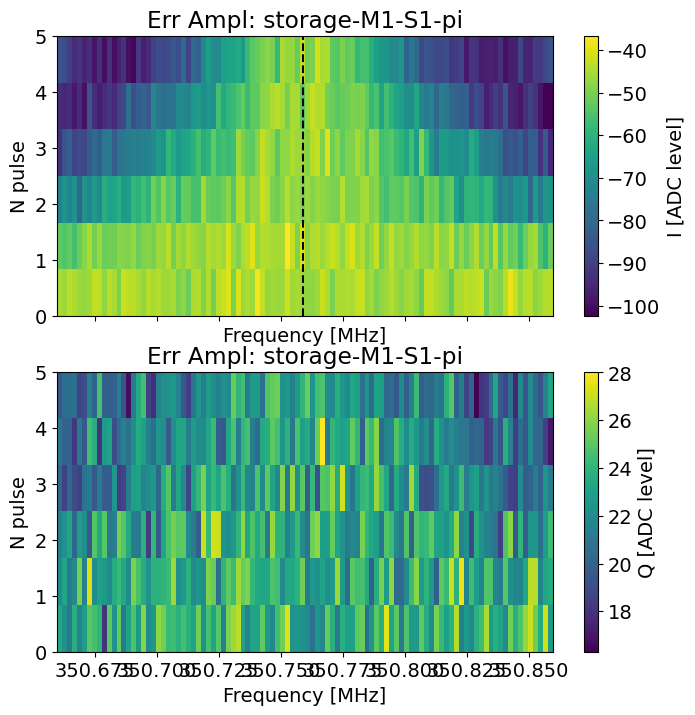

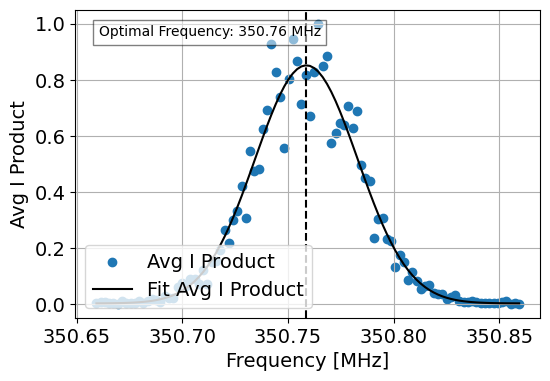

Previous freq 350.7587425566751, gain 5985, pi_len 0.9870180243812782
Job submitted: JOB-20260909-00065 (queue position: 1)

[2.1s] Job JOB-20260909-00065: running
[WORKER] Loading ErrorAmplificationExperiment from experiments.single_qubit.error_amplification
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260909-00065_ErrorAmplificationExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [01:06<00:00, 11.13s/it]
Saving C:\experiments\260701_Calibration\data\JOB-20260909-00065_ErrorAmplificationExperiment.h5
[WORKER] Saving expt object to: C:\experiments\260701_Calibration\expt_objs\JOB-20260909-00065_expt.pkl

[77.8s] Job JOB-20260909-00065: completed

Job completed! Data: C:\experiments\260701_Calibration\

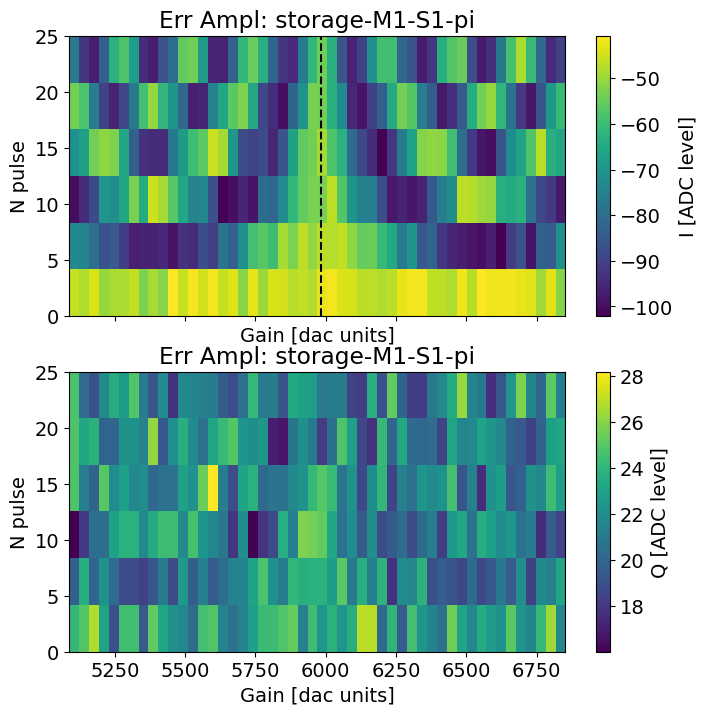

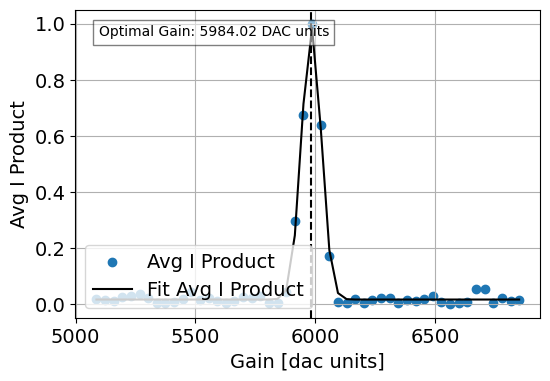

Running M1-S2
Previous freq 522.6162175104731, gain 6027, pi_len 1.0211200169327388
Job submitted: JOB-20260909-00066 (queue position: 1)

[19.0s] Job JOB-20260909-00066: running
[WORKER] Loading ErrorAmplificationExperiment from experiments.single_qubit.error_amplification
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260909-00066_ErrorAmplificationExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 83%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                       | 5/6 [00:35<00:07,  7.04s/it]
[56.7s] Job JOB-20260909-00066: completed
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:42<00:00,  7.04s/it]
Saving C:\experiments\260701_Calibration\data\JOB-20260909-00066

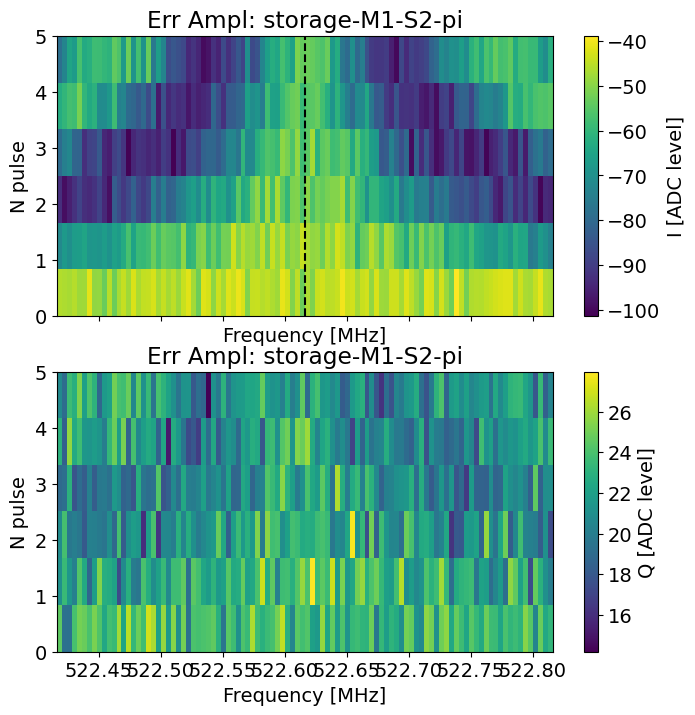

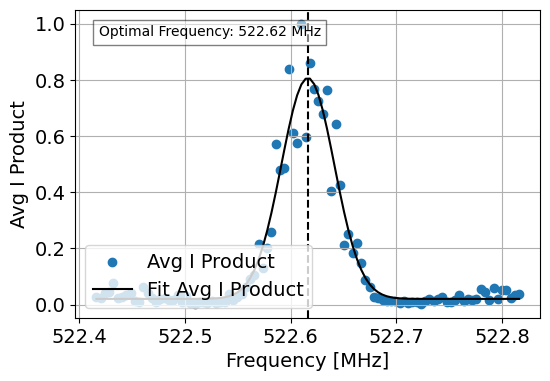

Previous freq 522.6162837865126, gain 6027, pi_len 1.0211200169327388
Job submitted: JOB-20260909-00067 (queue position: 1)

[12.2s] Job JOB-20260909-00067: running
[WORKER] Loading ErrorAmplificationExperiment from experiments.single_qubit.error_amplification
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260909-00067_ErrorAmplificationExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 67%|███████████████████████████████████████████████████████████████████████████████████████████████▎                                               | 4/6 [00:44<00:22, 11.11s/it]
[71.7s] Job JOB-20260909-00067: completed
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [01:06<00:00, 11.13s/it]
Saving C:\experiments\260701_Calibration\data\JOB-20260909-00067_ErrorAmplific

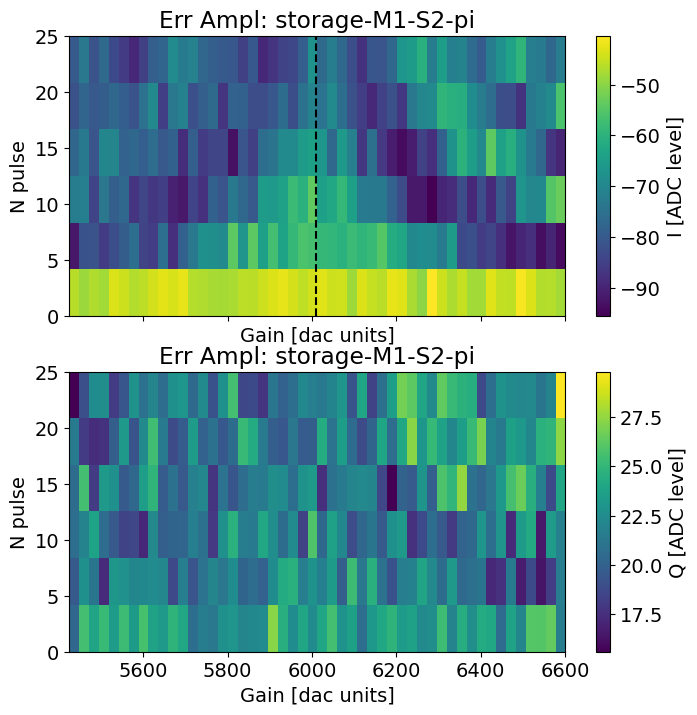

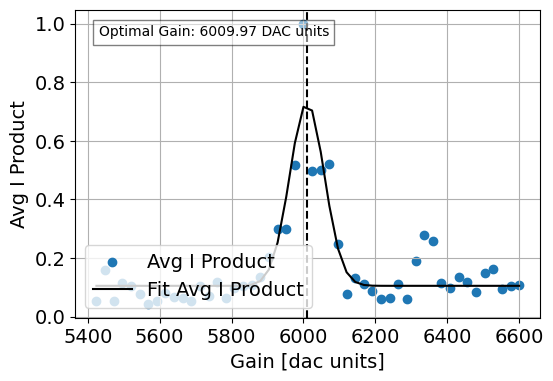

Running M1-S3
Previous freq 698.3511815351898, gain 5984, pi_len 1.0755201324453103
Job submitted: JOB-20260909-00068 (queue position: 1)

[6.7s] Job JOB-20260909-00068: running
[WORKER] Loading ErrorAmplificationExperiment from experiments.single_qubit.error_amplification
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260909-00068_ErrorAmplificationExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 67%|███████████████████████████████████████████████████████████████████████████████████████████████▎                                               | 4/6 [00:28<00:14,  7.11s/it]
[47.9s] Job JOB-20260909-00068: completed
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:42<00:00,  7.09s/it]
Saving C:\experiments\260701_Calibration\data\JOB-20260909-00068_

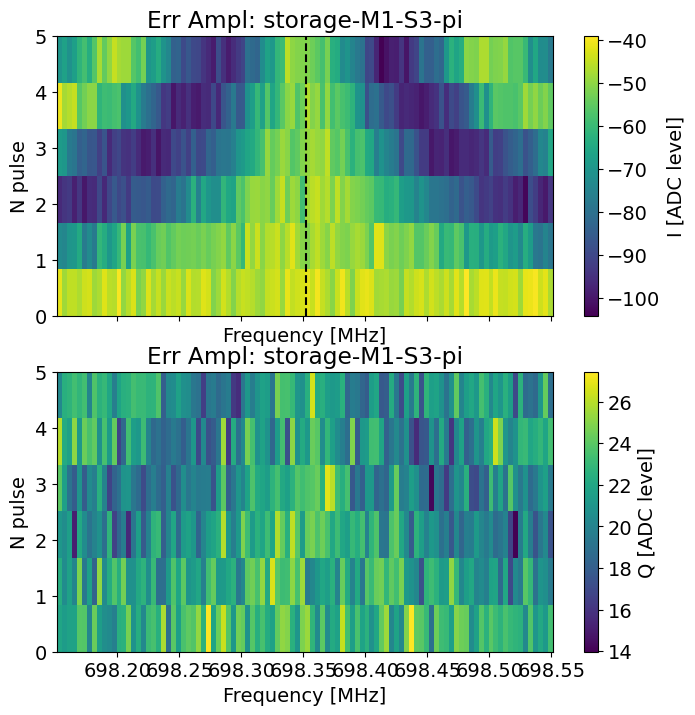

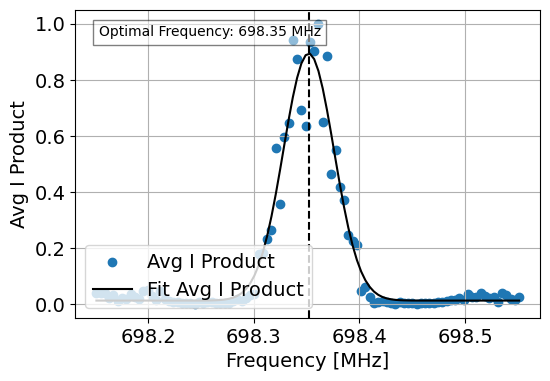

Previous freq 698.3520462546171, gain 5984, pi_len 1.0755201324453103
Job submitted: JOB-20260909-00069 (queue position: 1)

[2.1s] Job JOB-20260909-00069: running
[WORKER] Loading ErrorAmplificationExperiment from experiments.single_qubit.error_amplification
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260909-00069_ErrorAmplificationExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 83%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                       | 5/6 [00:55<00:11, 11.16s/it]
[90.7s] Job JOB-20260909-00069: completed
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [01:06<00:00, 11.14s/it]
Saving C:\experiments\260701_Calibration\data\JOB-20260909-00069_ErrorAmplifica

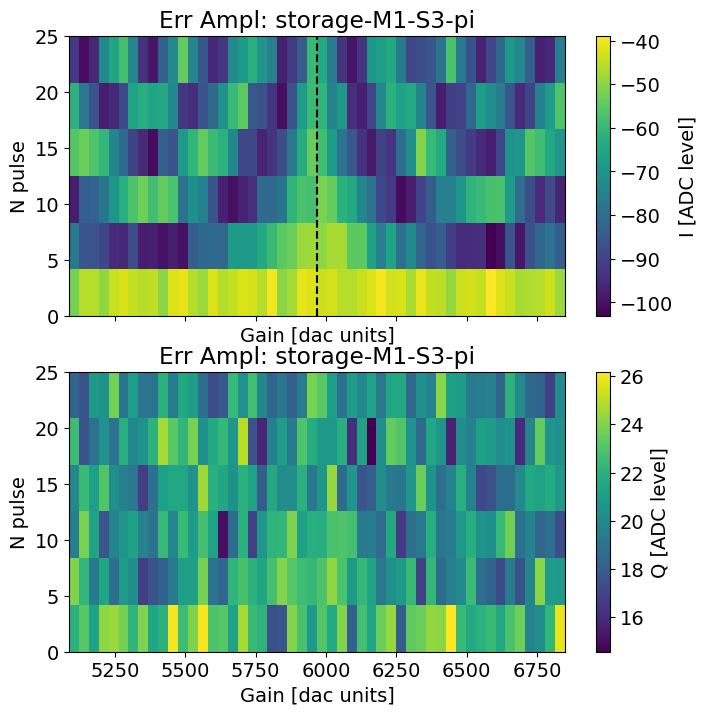

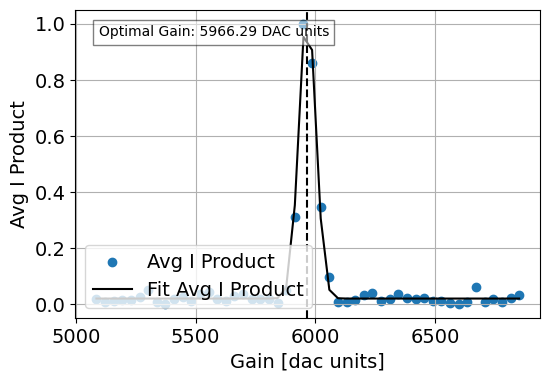

Running M1-S4
Previous freq 878.2398416476744, gain 9142, pi_len 1.724985488959412
Job submitted: JOB-20260909-00070 (queue position: 1)

[6.3s] Job JOB-20260909-00070: running
[WORKER] Loading ErrorAmplificationExperiment from experiments.single_qubit.error_amplification
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260909-00070_ErrorAmplificationExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:42<00:00,  7.06s/it]
Saving C:\experiments\260701_Calibration\data\JOB-20260909-00070_ErrorAmplificationExperiment.h5
[WORKER] Saving expt object to: C:\experiments\260701_Calibration\expt_objs\JOB-20260909-00070_expt.pkl

[72.7s] Job JOB-20260909-00070: completed

Job completed! Data: C:\experiments\260701

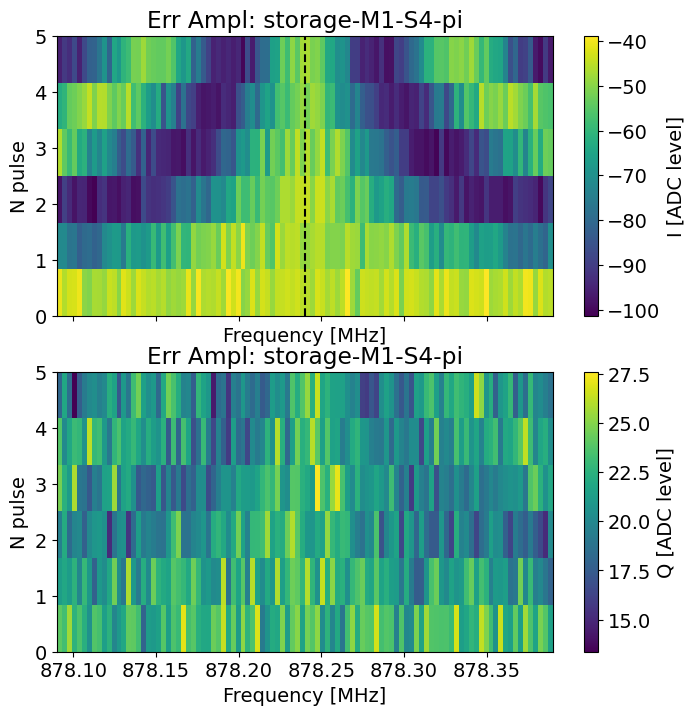

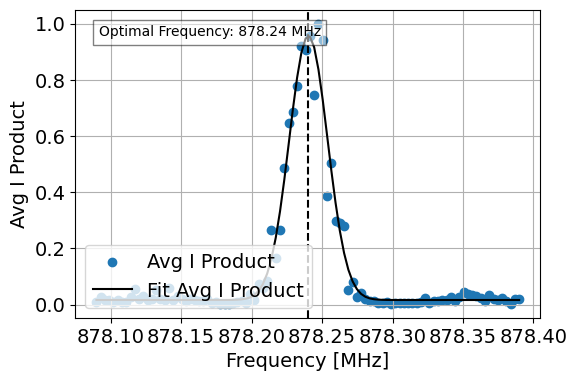

Previous freq 878.2402814186324, gain 9142, pi_len 1.724985488959412
Job submitted: JOB-20260909-00071 (queue position: 1)

[6.8s] Job JOB-20260909-00071: running
[WORKER] Loading ErrorAmplificationExperiment from experiments.single_qubit.error_amplification
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260909-00071_ErrorAmplificationExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [01:07<00:00, 11.18s/it]
Saving C:\experiments\260701_Calibration\data\JOB-20260909-00071_ErrorAmplificationExperiment.h5
[WORKER] Saving expt object to: C:\experiments\260701_Calibration\expt_objs\JOB-20260909-00071_expt.pkl

[79.9s] Job JOB-20260909-00071: completed

Job completed! Data: C:\experiments\260701_Calibration\d

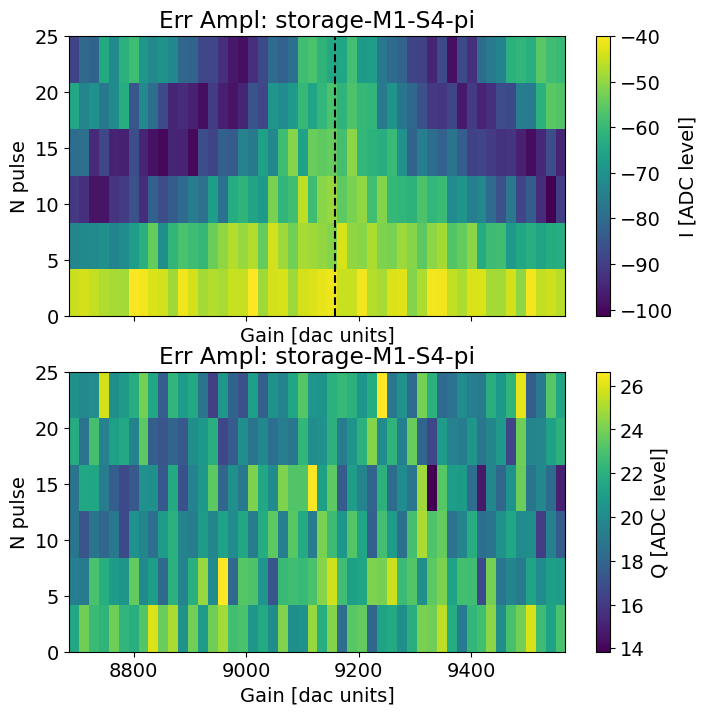

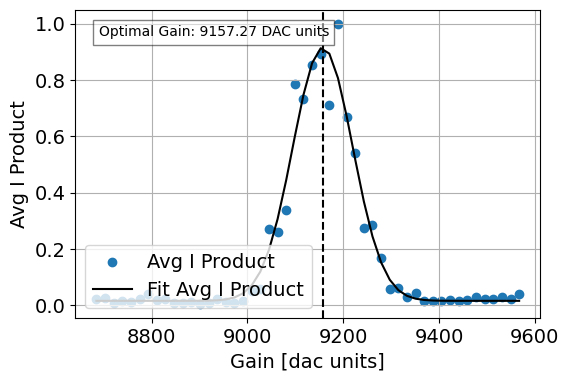

Running M1-S5
Previous freq 1054.2688741352854, gain 9613, pi_len 2.158181281157763
Job submitted: JOB-20260909-00072 (queue position: 1)

[6.6s] Job JOB-20260909-00072: running
[WORKER] Loading ErrorAmplificationExperiment from experiments.single_qubit.error_amplification
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260909-00072_ErrorAmplificationExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:42<00:00,  7.08s/it]
Saving C:\experiments\260701_Calibration\data\JOB-20260909-00072_ErrorAmplificationExperiment.h5
[WORKER] Saving expt object to: C:\experiments\260701_Calibration\expt_objs\JOB-20260909-00072_expt.pkl

[52.1s] Job JOB-20260909-00072: completed

Job completed! Data: C:\experiments\26070

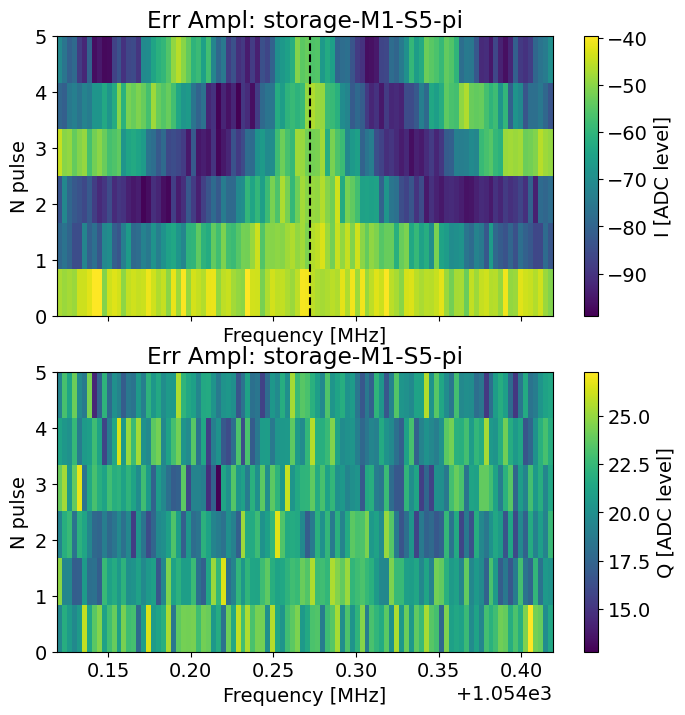

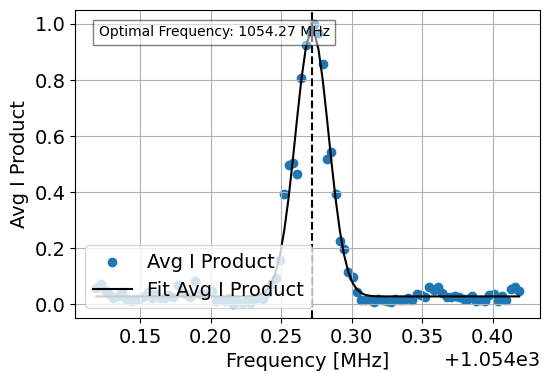

Previous freq 1054.2718921117446, gain 9613, pi_len 2.158181281157763
Job submitted: JOB-20260909-00073 (queue position: 1)

[10.9s] Job JOB-20260909-00073: running
[WORKER] Loading ErrorAmplificationExperiment from experiments.single_qubit.error_amplification
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260909-00073_ErrorAmplificationExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [01:07<00:00, 11.21s/it]
Saving C:\experiments\260701_Calibration\data\JOB-20260909-00073_ErrorAmplificationExperiment.h5
[WORKER] Saving expt object to: C:\experiments\260701_Calibration\expt_objs\JOB-20260909-00073_expt.pkl

[81.5s] Job JOB-20260909-00073: completed

Job completed! Data: C:\experiments\260701_Calibration

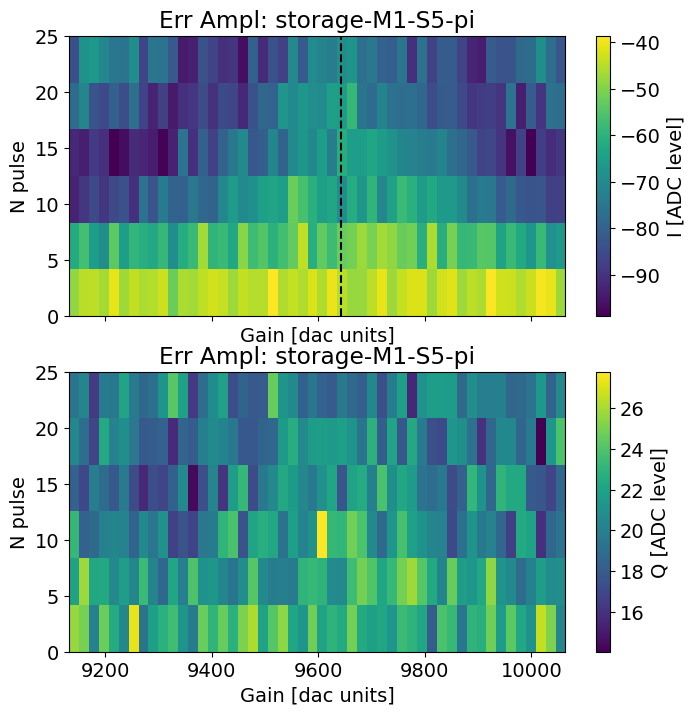

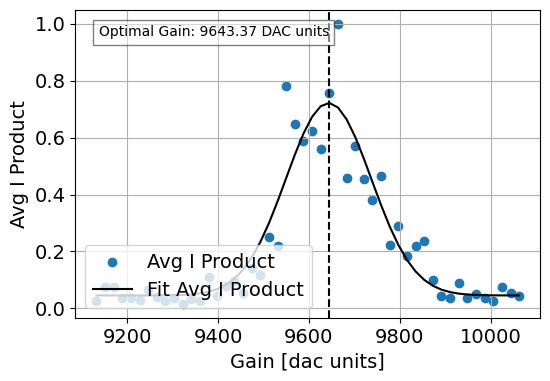

Running M1-S6
Previous freq 1248.3847110158104, gain 9000, pi_len nan
Job submitted: JOB-20260909-00074 (queue position: 1)

[6.0s] Job JOB-20260909-00074: failed
[WORKER] Loading ErrorAmplificationExperiment from experiments.single_qubit.error_amplification
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260909-00074_ErrorAmplificationExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
  0%|                                                                                                                                                       | 0/6 [00:00<?, ?it/s]

Job failed: ValueError: cannot convert float NaN to integer
Traceback (most recent call last):
  File "C:\python\multimode_expts\job_server\worker.py", line 366, in _execute_job
    data_file_path, expt_pickle_path = self._run_experiment(ExptClass, expt_config, job)
                                 

RuntimeError: Job JOB-20260909-00074 failed: ValueError: cannot convert float NaN to integer
Traceback (most recent call last):
  File "C:\python\multimode_expts\job_server\worker.py", line 366, in _execute_job
    data_file_path, expt_pickle_path = self._run_experiment(ExptClass, expt_config, job)
                                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\python\multimode_expts\job_server\worker.py", line 561, in _run_experiment
    expt.go(
  File "C:\python\multimode_expts\slab\experiment.py", line 173, in go
    data=self.acquire(progress)
         ^^^^^^^^^^^^^^^^^^^^^^
  File "C:\python\multimode_expts\experiments\single_qubit\error_amplification.py", line 341, in acquire
    self.prog = ErrorAmplificationProgram(soccfg=self.soccfg, cfg=cfg)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\python\multimode_expts\experiments\single_qubit\error_amplification.py", line 21, in __init__
    super().__init__(socc

In [130]:
span_list        = [0.2 ,  0.4,  0.4,  0.3,  0.3,  0.3, 0.2]
gain_pref_list   = [None,  0.2,  0.3,  0.1,  0.1, 0.15, 0.2] # should be less than 1.0
max_gain_list    = [None, 11000, None, None,None,None,None,]


n_step_list_freq = [None, None, None, None, None, None, None]
n_step_list_gain = [   5,    5,    5,    5,    5,    5,    5]

do_freq_erroramp = True
do_gain_erroramp = True


for i, stor_i in enumerate(expts_to_run['stor_modes']):
    if expts_to_run['sideband_erroramp']:
        stor_idx = stor_i - 1
        
        prefactor = gain_pref_list[stor_idx]
        if prefactor is None:
            prefactor = 0.3
        
        n_step_freq = n_step_list_freq[stor_idx]
        n_step_gain = n_step_list_gain[stor_idx]
        if n_step_freq is None:
            n_step_freq = 1
        if n_step_gain is None:
            n_step_gain = 1
        n_pulses_freq = 5 * n_step_freq
        n_pulses_gain = 5 * n_step_gain
        stor_name = 'M1-S' + str(stor_i)
        print("Running", stor_name)
        if do_freq_erroramp == True:
            error_amp_freq1[i] = error_amp_stor_runner.execute(
                stor_mode_no=stor_i,
                parameter_to_test='frequency',
                span=span_list[stor_idx], #0.1
                expts=100,
                n_step = n_step_freq,
                n_pulses = n_pulses_freq,
                active_reset=True,
                man_reset=True,
                storage_reset=[stor_i],
                relax_delay = 1000
            )
            if not station.log_measurements:
                error_amp_freq1[i].display()
        if do_gain_erroramp == True:
            error_amp_gain1[i] = error_amp_stor_runner.execute(
                stor_mode_no=stor_i,
                parameter_to_test='gain',
                span = int(station.ds_storage.get_gain(stor_name) * prefactor), 
                n_step = n_step_gain,
                n_pulses=n_pulses_gain,
                
                max_gain = max_gain_list[stor_idx], #add to autocalib nb

                
                active_reset=True,
                man_reset=True,
                storage_reset=[stor_i],
                relax_delay = 4000
            )
            if not station.log_measurements:
                error_amp_gain1[i].display()

# Floquet

In [131]:
from experiments.MM_dual_rail_base import MM_dual_rail_base

def get_floquet_parameters(station, man_mode_no, stor_mode_no):
    """
    Get pulse parameters for a given storage mode. 
    Also returns prepulse and postpulse (single photon prep and meas for ge meas)

    Args:
        station: MultimodeStation object for managing frequency data.
        man_mode_no: Manipulation mode number.
        stor_mode_no: Storage mode number.

    Returns:
        A tuple containing freq, gain, ch, prepulse, and postpulse.
    """
    stor_name = 'M' + str(man_mode_no) + '-S' + str(stor_mode_no)
    freq = station.ds_floquet.get_freq(stor_name)
    gain = station.ds_floquet.get_gain(stor_name)
    length = station.ds_floquet.get_len(stor_name)
    pi_frac = station.ds_floquet.get_pi_frac(stor_name)
    ch = 'low' if freq < 1000 else 'high'

    mm_base_dummy = MM_dual_rail_base(station.hardware_cfg, station.soccfg)
    prep_man_pi = mm_base_dummy.prep_man_photon(man_mode_no)
    prepulse = mm_base_dummy.get_prepulse_creator(prep_man_pi).pulse.tolist()
    postpulse = mm_base_dummy.get_prepulse_creator(prep_man_pi[-1:-3:-1]).pulse.tolist() # for ge meas, only do f0g1 and ef pi

    return freq, gain, length, pi_frac, ch, prepulse, postpulse


## Chevron

In [132]:
floquet_freq_chev_defaults = AttrDict(dict(
    expts = 1,
    reps = 100,
    rounds = 1,
    qubits = [0],
    ro_stor = 0, # storage mode number that gets read out in the end
    f0g1_cavity = 1,  #  1/2 name of manipulate cavity
    # if 0, this means to read out man instead
    detunes=np.linspace(-0.3, 0.3, 11).tolist(),
    swept_params = ['detune', 'length'],
    normalize = False,
    active_reset = False,
    man_reset = False, 
    storage_reset = False, 
    prepulse=True,
    postpulse=True,
    init_fock=True,
)) # Shouldn't be modifying this on the fly!
floquet_freq_chev_defaults.update(active_reset_default_dict)
floquet_freq_chev_defaults.update(floquet_default_dict)
# You can use kwargs in the run function to override these values

def floquet_freq_chev_preproc(station, default_expt_cfg, **kwargs):
    assert 'init_stor' in kwargs
    expt_cfg = deepcopy(default_expt_cfg)
    ds_floquet = station.ds_floquet
    init_stor = kwargs.pop('init_stor') # storage mode number to initialize to n=1 Fock state
    lengths = np.linspace(0.01, 3.0 * ds_floquet.get_len(f'M1-S{init_stor}'), 10).tolist()

    expt_cfg.init_stor = init_stor
    expt_cfg.lengths = lengths
    expt_cfg.update(kwargs)
    print(expt_cfg)
    return expt_cfg

def floquet_freq_chev_postproc(station, expt):
    expt_cfg = expt.cfg.expt
    stor_name = f'M{expt_cfg.f0g1_cavity}-S{expt_cfg.init_stor}'

    from fitting.fit_display_classes import ChevronFitting

    chevron_analysis = ChevronFitting(
        frequencies=np.array(expt.data['ypts']),
        time=np.array(expt.data['xpts']),
        response_matrix=expt.data['avgi'],
        config=station.hardware_cfg,
        station=station,
    )

    chevron_analysis.analyze()
    
    best_detune = chevron_analysis.results.get('best_frequency_contrast')

    if best_detune is not None:
        pi_frac = station.ds_floquet.get_pi_frac(stor_name)
        print(f"Best detune found: {best_detune:.4f} MHz")
        current_freq = station.ds_floquet.get_freq(stor_name)
        new_freq = current_freq + best_detune
        station.ds_floquet.update_freq(stor_name, new_freq)
        print(f"Updated {stor_name} frequency to {new_freq:.4f} MHz")
        frac_pi_len = abs(np.pi / chevron_analysis.results['best_fit_params_period']['omega'])
        station.ds_floquet.update_len(stor_name, frac_pi_len)
        print(f'Updated the pi/{pi_frac} length from {station.ds_floquet.get_len(stor_name):.4f} to {frac_pi_len:.4f}')
    
    chevron_analysis.display_results()
    expt.analysis = chevron_analysis
    station.snapshot_floquet_storage_swap(update_main=False)

### Coarse

In [133]:
stor_modes_to_run = expts_to_run['floquet_stor_modes'] #list(range(1,8))
freq_len_expt = [None] * len(stor_modes_to_run)

floquet_freq_chev_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.FloquetChevronExperiment,
    ExptProgram=meas.FloquetChevronProgram,
    default_expt_cfg=floquet_freq_chev_defaults,
    preprocessor=floquet_freq_chev_preproc,
    postprocessor=floquet_freq_chev_postproc,
    job_client=client,
)

for i, init_stor in enumerate(stor_modes_to_run):
    if expts_to_run['floquet_chevron_coarse']:
        # ds_floquet.update_gain(f'M1-S{init_stor}', ds_floquet.get_gain(f'M1-S{init_stor}') * 0.75)
        # print(f'Updating gain for M1-S{init_stor} to {ds_floquet.get_gain(f"M1-S{init_stor}")}')

        print(f'Running Floquet Frequency vs Length Chevron for Storage Mode {init_stor}')
        freq_len_expt[i] = floquet_freq_chev_runner.execute(
            init_stor=init_stor,
            # detunes=np.linspace(-0.2, 0.2, 51).tolist(),
            detunes=np.linspace(-1, 1, 51).tolist(),
            reps=100,
            
            # relax_delay=8000,
            relax_delay = 200,
            active_reset=True,
            man_reset=True, 
            storage_reset=[init_stor], 
            reset_dump_mode = active_reset_default_dict["reset_dump_mode"],
            dump_reset_iter_num = active_reset_default_dict["dump_reset_iter_num"],
        )
        # freq_len_expt[i].display()
        # clear_output(wait=True)

### Fine

In [134]:
stor_modes_to_run = expts_to_run['floquet_stor_modes'] #list(range(1,8))
freq_len_expt  = [None] * len(stor_modes_to_run)
freq_span_expt = [ 0.5,  0.3, None, None,  0.2,  0.2,  0.2]



floquet_freq_chev_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.FloquetChevronExperiment,
    ExptProgram=meas.FloquetChevronProgram,
    default_expt_cfg=floquet_freq_chev_defaults,
    preprocessor=floquet_freq_chev_preproc,
    postprocessor=floquet_freq_chev_postproc,
    job_client=client,
)

for i, init_stor in enumerate(stor_modes_to_run):
    if expts_to_run['floquet_chevron_fine']:
        # ds_floquet.update_gain(f'M1-S{init_stor}', ds_floquet.get_gain(f'M1-S{init_stor}') * 0.75)
        # print(f'Updating gain for M1-S{init_stor} to {ds_floquet.get_gain(f"M1-S{init_stor}")}')
        stor_idx = init_stor - 1
        freq_span = freq_span_expt[stor_idx]
        if freq_span is None:
            freq_span = 1.0
        print(f'Running Floquet Frequency vs Length Chevron for Storage Mode {init_stor}')
        freq_len_expt[i] = floquet_freq_chev_runner.execute(
            init_stor=init_stor,
            detunes=np.linspace(-freq_span, freq_span, 51).tolist(),
            reps=100,
            
            relax_delay = 200, #8000
            active_reset=True,
            man_reset=True, 
            storage_reset=[init_stor], 
            reset_dump_mode = active_reset_default_dict["reset_dump_mode"],
            dump_reset_iter_num = active_reset_default_dict["dump_reset_iter_num"],
        )
        if not station.log_measurements:
            freq_len_expt[i].display()
        # clear_output(wait=True)

## Error amplification on floquet pulses

In [135]:
error_amp_floquet_defaults = AttrDict(dict(
    reps=100,
    rounds=1,
    qubits=[0],
    active_reset=False,
    man_mode_no=1,
    stor_is_dump=False,
    man_reset=True,
    storage_reset=True,
    relax_delay=2500, 
    expts=25,
    qubit_start_storage='g',
    floquet_hardware_loop=floquet_default_dict["floquet_hardware_loop"],
    floquet_sync_delay=floquet_default_dict["scramble_sync_cycles"]
)) # Shouldn't be modifying this on the fly!
error_amp_floquet_defaults.update(active_reset_default_dict)
error_amp_floquet_defaults.update(floquet_default_dict)
# You can use kwargs in the run function to override these values

error_amp_gain_floquet_coarse_defaults = AttrDict(dict(
    n_pulses=8,
    span=4000,#4000
    expts=30,#30
))

error_amp_freq_floquet_coarse_defaults = AttrDict(dict(
    n_pulses=7,
    span=0.25,
    expts=50,
))


def error_amp_floquet_preproc(station, default_expt_cfg, **kwargs):
    assert 'stor_mode_no' in kwargs
    assert 'parameter_to_test' in kwargs 

    # construct the defaults
    expt_cfg = deepcopy(default_expt_cfg)
    if kwargs['parameter_to_test'] == 'gain':
        expt_cfg.update(error_amp_gain_floquet_coarse_defaults)
    elif kwargs['parameter_to_test'] == 'frequency':
        expt_cfg.update(error_amp_freq_floquet_coarse_defaults)
    # override with the passed kwargs
    expt_cfg.update(kwargs)

    freq, gain, length, pi_frac, ch, prepulse, postpulse = get_floquet_parameters(station, expt_cfg.man_mode_no, expt_cfg.stor_mode_no)
    pulse_type = ['floquet', f'M{expt_cfg.man_mode_no}-{"D" if expt_cfg.stor_is_dump else "S"}{expt_cfg.stor_mode_no}', f'pi/{pi_frac}', 0]
    # freq = 695.7
    # gain = 10000
    if expt_cfg.parameter_to_test == 'frequency':
        start = freq - expt_cfg.span / 2
        step = expt_cfg.span / (expt_cfg.expts - 1)
    elif expt_cfg.parameter_to_test == 'gain':
        start = int(gain - expt_cfg.span / 2)
        step = int(expt_cfg.span / (expt_cfg.expts - 1))
    else:
        raise ValueError("parameter_to_test must be either 'frequency' or 'gain'.")
    expt_cfg.start = start
    expt_cfg.step = step
    expt_cfg.pulse_type = pulse_type 
    return expt_cfg

def error_amp_floquet_postproc(station, expt):
    expt.analyze(data=expt.data, state_fin='e')

    opt_val = expt.data['fit_avgi'][2]
    stor_name = 'M1-S' + str(expt.cfg.expt.stor_mode_no)
    if expt.cfg.expt.parameter_to_test == 'gain':
        station.ds_floquet.update_gain(stor_name, opt_val)
        print(f'Updated gain for {stor_name} to {opt_val}')
    elif expt.cfg.expt.parameter_to_test == 'frequency':
        station.ds_floquet.update_freq(stor_name, opt_val)
        print(f'Updated frequency for {stor_name} to {opt_val}')
    station.snapshot_floquet_storage_swap(update_main=False)


error_amp_floquet_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.single_qubit.error_amplification.ErrorAmplificationExperiment,
    default_expt_cfg=error_amp_floquet_defaults,
    preprocessor=error_amp_floquet_preproc,
    postprocessor=error_amp_floquet_postproc,
    job_client=client,
)

In [136]:
stor_modes_to_run = expts_to_run['floquet_stor_modes']
# stor_modes_to_run = [2, 7]
error_amp_gain1 = [None] * len(stor_modes_to_run)
error_amp_freq1 = [None] * len(stor_modes_to_run)
error_amp_gain2 = [None] * len(stor_modes_to_run)
error_amp_freq2 = [None] * len(stor_modes_to_run)


freq_span_list = [0.1,  0.1,  None,  0.1,   0.1, None, None] # set for the Coarse
gain_span_list = [None, None, None, None,  0.15, None, None]

### Coarse

In [137]:
freq_span_default = 0.1
gain_span_default = 0.3

do_freq_erroramp = True
do_gain_erroramp = True

if expts_to_run['floquet_error_amplificaton_coarse']:
    for i, stor_i in enumerate(stor_modes_to_run):
        stor_idx = stor_i - 1
        stor_name = 'M1-S' + str(stor_i)
        
        freq_span = freq_span_default if freq_span_list[stor_idx] is None else freq_span_list[stor_idx]
        gain_span = gain_span_default if gain_span_list[stor_idx] is None else gain_span_list[stor_idx]
        
        if do_freq_erroramp:
            error_amp_freq1[i] = error_amp_floquet_runner.execute(
                stor_mode_no=stor_i,
                parameter_to_test='frequency',
                go_kwargs=dict(analyze=False, progress=True, display=False),
                span = freq_span, # 0.2 is default, but we want to be more precise since we are already close
                
                # relax_delay=8000,
                relax_delay = 200,
                active_reset=True,
                man_reset=True, 
                storage_reset=[stor_i], 
                reset_dump_mode = active_reset_default_dict["reset_dump_mode"],
                dump_reset_iter_num = active_reset_default_dict["dump_reset_iter_num"],
            )
            if not station.log_measurements:
                error_amp_freq1[i].display()
        if do_gain_erroramp:
            error_amp_gain1[i] = error_amp_floquet_runner.execute(
                stor_mode_no=stor_i,
                parameter_to_test='gain',   
                go_kwargs=dict(analyze=False, progress=True, display=False),
                span=int(station.ds_floquet.get_gain(stor_name) * gain_span), #0.7 is default
                # span = 59,
                expts = 60,
                # expts=60,
                
                # relax_delay=8000,
                relax_delay = 200,
                active_reset=True,
                man_reset=True, 
                storage_reset=[stor_i], 
                reset_dump_mode = active_reset_default_dict["reset_dump_mode"],
                dump_reset_iter_num = active_reset_default_dict["dump_reset_iter_num"],
            )
            if not station.log_measurements:
                error_amp_gain1[i].display()

### Fine

In [ ]:
freq_span_default = 0.1
gain_span_default = 0.3

do_freq_erroramp = True
do_gain_erroramp = True

if expts_to_run['floquet_error_amplificaton_fine']:
    for i, stor_i in enumerate(stor_modes_to_run):
        stor_idx = stor_i - 1
        stor_name = 'M1-S' + str(stor_i)
        
        freq_span = freq_span_default if freq_span_list[stor_idx] is None else freq_span_list[stor_idx]
        gain_span = gain_span_default if gain_span_list[stor_idx] is None else gain_span_list[stor_idx]
        
        if do_freq_erroramp:
            error_amp_freq1[i] = error_amp_floquet_runner.execute(
                stor_mode_no=stor_i,
                parameter_to_test='frequency',
                go_kwargs=dict(analyze=False, progress=True, display=False),
                span = freq_span / 2, # 0.2 is default, but we want to be more precise since we are already close
                
                # relax_delay=8000,
                relax_delay = 200,
                active_reset=True,
                man_reset=True, 
                storage_reset=[stor_i], 
                reset_dump_mode = active_reset_default_dict["reset_dump_mode"],
                dump_reset_iter_num = active_reset_default_dict["dump_reset_iter_num"],
            )
            if not station.log_measurements:
                error_amp_freq1[i].display()
        if do_gain_erroramp:
            error_amp_gain1[i] = error_amp_floquet_runner.execute(
                stor_mode_no=stor_i,
                parameter_to_test='gain',   
                go_kwargs=dict(analyze=False, progress=True, display=False),
                span=int(station.ds_floquet.get_gain(stor_name) * gain_span / 2), #0.7 is default
                # span = 59,
                expts = 60,
                # expts=60,
                
                # relax_delay=8000,
                relax_delay = 200,
                active_reset=True,
                man_reset=True, 
                storage_reset=[stor_i], 
                reset_dump_mode = active_reset_default_dict["reset_dump_mode"],
                dump_reset_iter_num = active_reset_default_dict["dump_reset_iter_num"],
            )
            if not station.log_measurements:
                error_amp_gain1[i].display()

Job submitted: JOB-20260909-00075 (queue position: 1)

[2.2s] Job JOB-20260909-00075: running


## Phase Accumulation

In [ ]:
phase_expts = [[None for _ in range(7)] for _ in range(7)]

In [ ]:
sideband_stark_error_amp_defaults = AttrDict(dict(
    expts=1,
    reps=100,
    rounds=1,
    qubits=[0],
    f0g1_cavity=1,  #  1/2 name of manipulate cavity
    init_stor=0, # storage mode number to initialize to n=1 Fock state (0=man)
    ro_stor=0, # storage mode number that gets read out in the end (0=man)
    advance_phases=np.linspace(-15, 15, 51).tolist(),
    n_pulses=np.arange(0, 24, 4).tolist(),
    swept_params=['n_pulse', 'advance_phase'],
    normalize=False, # not sure what this does
    active_reset=False,
    man_reset=False, 
    storage_reset=False, 
    prepulse=True,
    postpulse=True,
    init_fock=True,
))
sideband_stark_error_amp_defaults.update(active_reset_default_dict)
sideband_stark_error_amp_defaults.update(floquet_default_dict)

def sideband_stark_error_amp_preproc(station, default_expt_cfg, **kwargs):
    assert 'stor_A' in kwargs
    assert 'stor_B' in kwargs

    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    print(expt_cfg)
    return expt_cfg

def sideband_stark_error_amp_postproc(station, expt):
    storA = expt.cfg.expt.stor_A
    storB = expt.cfg.expt.stor_B
    stor_name = 'M1-S' + str(storA)
    from_stor_name = 'M1-S' + str(storB)
    expt.analyze(fit=True)
    expt.display(fit=True)
    # opt_phase = expt.data['fit_avgi'][2] / 2 # divide by 2 since did pi/12, -pi/12 on the from_stor swap
    opt_phase = expt.data['fit_avgi'][2] # not dividing seems to give the correct result somehow? TODO: figure out why
    print("Opt phase on", stor_name, "from", from_stor_name, ":", opt_phase)
    station.ds_floquet.update_phase_from(stor_name, from_stor_name, opt_phase)
    station.snapshot_floquet_storage_swap(update_main=False)

sideband_stark_error_amp_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.SidebandStarkAmplificationExperiment,
    ExptProgram=meas.SidebandStarkAmplificationProgram., #meas.SidebandStarkAmplificationProgram,
    default_expt_cfg=sideband_stark_error_amp_defaults,
    preprocessor=sideband_stark_error_amp_preproc,
    postprocessor=sideband_stark_error_amp_postproc,
    job_client=client,
)

In [ ]:
station.ds_floquet.df

### Coarse

In [ ]:
stor_modes_to_run =  expts_to_run['floquet_stor_modes']


if expts_to_run['floquet_phase_accumulation_matrix_coarse']:
    for iA, init_storA in enumerate(stor_modes_to_run): #range(1,8):
        for iB, init_storB in enumerate(stor_modes_to_run): #range(1,8):
            if init_storA == init_storB:
                continue
            print("Starting experiment for storage modes:", init_storA, "from", init_storB)

            qbe = sideband_stark_error_amp_runner.execute(
                stor_A=init_storA,
                stor_B=init_storB,
                # relax_delay=8000,
                relax_delay = 100,
                active_reset=True,
                man_reset=True, 
                storage_reset=[init_storA, init_storB], 
                reset_dump_mode = active_reset_default_dict["reset_dump_mode"],
                dump_reset_iter_num = active_reset_default_dict["dump_reset_iter_num"],
                reps=100,
                include_10cycles_buffer = floquet_default_dict["include_10cycles_buffer"],
                include_10cycles_buffer_in_pi_half = floquet_default_dict["include_10cycles_buffer_in_pi_half"],
                advance_phases=np.linspace(-20, 20, 51).tolist(),
                # n_pulses=np.arange(0, 42, 7).tolist(),
            )
            phase_expts[init_storA - 1][init_storB - 1] = qbe

### Fine

In [ ]:
stor_modes_to_run =  expts_to_run['floquet_stor_modes']

if expts_to_run['floquet_phase_accumulation_matrix_fine']:
    for iA, init_storA in enumerate(stor_modes_to_run): #range(1,8):
        for iB, init_storB in enumerate(stor_modes_to_run): #range(1,8):
            if init_storA == init_storB:
                continue
            print("Starting experiment for storage modes:", init_storA, "from", init_storB)
            _phase_center = station.ds_floquet.get_phase_from(f'M1-S{init_storA}', f"M1-S{init_storB}")
            _phase_start = _phase_center - expts_to_run['floquet_phase_accumulation_matrix_fine_bw']/2
            _phase_end   = _phase_center + expts_to_run['floquet_phase_accumulation_matrix_fine_bw']/2
            
            qbe = sideband_stark_error_amp_runner.execute(
                stor_A=init_storA,
                stor_B=init_storB,
                # relax_delay=8000,
                relax_delay = 100,
                active_reset=True,
                man_reset=True, 
                storage_reset=[init_storA, init_storB], 
                reset_dump_mode = active_reset_default_dict["reset_dump_mode"],
                dump_reset_iter_num = active_reset_default_dict["dump_reset_iter_num"],
                reps=100,
                include_10cycles_buffer = floquet_default_dict["include_10cycles_buffer"],
                include_10cycles_buffer_in_pi_half = floquet_default_dict["include_10cycles_buffer_in_pi_half"],
                advance_phases=np.linspace(_phase_start, 
                                           _phase_end, 
                                           101).tolist(),
                n_pulses=np.arange(0, 48, 8).tolist(),
            )
            phase_expts[init_storA - 1][init_storB - 1] = qbe

# MultiPhoton

In [ ]:
def fetch_initparam_to_mp(station):
    f_ge = station.hardware_cfg.device.qubit.f_ge[0]
    f_ef = station.hardware_cfg.device.qubit.f_ef[0]
    f_f0g1 = station.hardware_cfg.device.multiphoton.pi['fn-gn+1']['frequency'][0]
    
    gain_ge = station.hardware_cfg.device.qubit.pulses['pi_ge']['gain'][0]
    gain_ef = station.hardware_cfg.device.qubit.pulses['pi_ef']['gain'][0]
    gain_f0g1 = station.hardware_cfg.device.multiphoton.pi['fn-gn+1']['gain'][0]
    length_f0g1 =  station.hardware_cfg.device.multiphoton.pi['fn-gn+1']['length'][0]
    
    for i in range(len(station.hardware_cfg.device.multiphoton.pi['gn-en']['frequency'])):
        station.hardware_cfg.device.multiphoton.pi['gn-en']['frequency'][i] = f_ge
        station.hardware_cfg.device.multiphoton.pi['gn-en']['gain'][i] = gain_ge
        
        station.hardware_cfg.device.multiphoton.pi['en-fn']['frequency'][i] = f_ef
        station.hardware_cfg.device.multiphoton.pi['en-fn']['gain'][i] = gain_ef
        
        station.hardware_cfg.device.multiphoton.pi['fn-gn+1']['frequency'][i] = f_f0g1
        station.hardware_cfg.device.multiphoton.pi['fn-gn+1']['gain'][i] = gain_f0g1
        station.hardware_cfg.device.multiphoton.pi['fn-gn+1']['length'][i] = length_f0g1

In [ ]:
if expts_to_run['multiphoton_fetch_from_singlequbit']:
    fetch_initparam_to_mp(station)

## Error Amplification of Qubit Pulses

In [ ]:
mm_base_calib = MM_dual_rail_base(station.hardware_cfg, station.soccfg)


# Error Amplification - Runner Pattern with CharacterizationRunner
# =====================================
error_amp_defaults = AttrDict(dict(
    reps=100,
    rounds=1,
    qubit=0,
    n_pulses=10,
    active_reset=False,
    man_reset=True,
    storage_reset=True,
    reset_dump_mode = active_reset_default_dict["reset_dump_mode"],
    dump_reset_iter_num = active_reset_default_dict["dump_reset_iter_num"],
    relax_delay=2500,
    start=0,
    expts=10,
    step=100,
    parameter_to_test='gain',  # 'gain' or 'frequency'
    pulse_type=['qubit', 'ge', 'pi', 0],
    # Multiphoton-specific parameters
    man_no=1,  # Manipulate mode number
    pulse_name='pi',  # 'pi' or 'hpi'
))


def error_amp_preproc_multiphoton(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    
    # Handle multiphoton transition
    if expt_cfg.pulse_type[0] == 'multiphoton':
        transition = expt_cfg.pulse_type[1]
        expt_cfg._photon_idx = int(transition[1])  # photon number from transition string
        # Store transition info for postprocessor
        if transition[0] == 'e' or transition[0] == 'g':
            expt_cfg._transition_key = transition[0] + 'n' + '-' + transition[3] + 'n'
        elif transition[0] == 'f':
            expt_cfg._transition_key = transition[0] + 'n' + '-' + transition[3] + 'n+1'
        else:
            raise ValueError(f"Unknown transition format: {transition}") 
    # Add qubits list if not present
    expt_cfg.qubits = [expt_cfg.qubit]
    
    return expt_cfg

def error_amp_postproc_multiphoton(station, expt, state_fin='g'):
    """Update config based on error amplification results.
    
    For multiphoton transitions, updates the multiphoton config.
    For standard qubit calibration, updates the qubit pulse params.
    """
    expt_cfg = expt.cfg.expt
    parameter = expt_cfg.parameter_to_test
    pulse_name = expt_cfg.pulse_type[2]  # 'pi' or 'hpi'
    print(f'Processing error amplification for parameter: {parameter}, pulse: {pulse_name}')


    if state_fin == 'e':
        expt.analyze(data=expt.data, state_fin='e')
        expt.display(data=expt.data, state_fin='e')

    
    # Get the optimal value from the experiment data
    # Error amplification typically finds the value that minimizes error
    if 'optimal_value' in expt.data:
        optimal_val = expt.data['optimal_value']

    if 'fit_avgi' in expt.data:
        print('parameter:', parameter)
        if parameter == 'frequency':
            optimal_val = expt.data['fit_avgi'][2]
        elif parameter == 'gain':
            optimal_val = int(expt.data['fit_avgi'][2])
        else: 
            raise ValueError(f"Unknown parameter to test: {parameter}")

    else:
        # If no automatic extraction, user needs to analyze manually
        print('No automatic optimal value extraction. Please analyze the data manually.')
        return
    
    if hasattr(expt_cfg, '_transition_key') and expt_cfg.pulse_type[0] == 'multiphoton':
        # Multiphoton transition update
        _transition = expt_cfg._transition_key
        i = expt_cfg._photon_idx
        
        old_val = station.hardware_cfg.device.multiphoton[pulse_name][_transition][parameter][i]
        station.hardware_cfg.device.multiphoton[pulse_name][_transition][parameter][i] = optimal_val
        print(f'Updated multiphoton {_transition} {pulse_name} {parameter} for photon {i}:')
        print(f'  {old_val} -> {optimal_val}')
    else:
        # Standard qubit update
        pulse_key = f'pi_ge' if pulse_name == 'pi' else f'hpi_ge'
        old_val = station.hardware_cfg.device.qubit.pulses[pulse_key][parameter][0]
        station.hardware_cfg.device.qubit.pulses[pulse_key][parameter] = [optimal_val]
        print(f'Updated qubit {pulse_key} {parameter}: {old_val} -> {optimal_val}')


length_rabi_f0g1_defaults = AttrDict(dict(
    man_mode_no=1,
    start=None,
    step=0.045,
    qubits=[0],
    expts=50,
    reps=100,
    rounds=1,
    gain=8000,
    freq=None,
    use_arb_waveform=False,
    pi_ge_before=False,
    pi_ef_before=False,
    pi_ge_after=False,
    normalize=False,
    active_reset=False,
    man_reset=True, 
    stor_reset=True,
    check_man_reset=[False, 0],
    swap_lossy=False,
    check_man_reset_pi=[],
    prepulse=False, 
    postpulse=False,
    post_sweep_pulse=None,
    pre_sweep_pulse=None,
    err_amp_reps=0,
    relax_delay=2500,
))

def do_length_rabi_f0g1_proproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)

    if expt_cfg.transition is not None:
        transition = expt_cfg.transition
        i = int(transition[1])  # photon number from transition string
        
        # Build pre_sweep_pulse based on transition
        pre_sweep_pulse = mm_base_calib.prep_man_photon(man_no=expt_cfg.man_mode_no, photon_no=i)
        pre_sweep_pulse.append(['multiphoton', 'g' + str(i) + '-e' + str(i), 'pi', 0])
        pre_sweep_pulse.append(['multiphoton', 'e' + str(i) + '-f' + str(i), 'pi', 0])  
        expt_cfg.pre_sweep_pulse = mm_base_calib.get_prepulse_creator(pre_sweep_pulse, station.hardware_cfg).pulse.tolist()
        expt_cfg.prepulse = len(expt_cfg.pre_sweep_pulse) > 0
        expt_cfg._transition_key = transition[0] + 'n' + '-' + transition[3] + 'n+1'
        expt_cfg._photon_idx = i  

        print('pre pulse:', expt_cfg.pre_sweep_pulse)



        if expt_cfg.freq is None:
            freq = station.hardware_cfg.device.multiphoton['pi'][expt_cfg._transition_key]['frequency'][expt_cfg._photon_idx]
            expt_cfg.freq = freq


    if expt_cfg.start is None:
        expt_cfg.start =  station.soccfg.cycles2us(3)

    return expt_cfg

def length_rabi_f0g1_postproc(station, expt):
    man_mode_no = expt.cfg.expt.man_mode_no

    # Get analysis results from the LengthRabiFitting object stored in expt
    if hasattr(expt, '_length_rabi_analysis'):
        analysis = expt._length_rabi_analysis
        pi_length = analysis.results['pi_length']
        pi2_length = analysis.results['pi2_length']
        gain = expt.cfg.expt.gain
        freq = expt.cfg.expt.freq

    if hasattr(expt.cfg.expt, '_transition_key') and expt.cfg.expt.get('transition') is not None:
        _transition = expt.cfg.expt._transition_key
        i = expt.cfg.expt._photon_idx
        
        old_pi_length = station.hardware_cfg.device.multiphoton['pi'][_transition]['length'][i]
        
        station.hardware_cfg.device.multiphoton['pi'][_transition]['length'][i] = pi_length
        
        print(f'Updated multiphoton {_transition} pi lengths for photon {i}:')
        print(f'  pi length: {old_pi_length} -> {pi_length}')

### Spectroscopy and Chevron helpers for Sideband. Should be refactored

In [ ]:
qspec_defaults = AttrDict(dict(
    man_mode_no=1,
    start=1999, 
    step=0.01, 
    expts=500,
    reps=500, 
    rounds=1, 
    length=1,
    gain=1000, 
    pulse_type='gaussian',
    qubit_f=False, 
    qubits=[0],
    transition=None,
    relax_delay=200,
))

def qspec_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)

    if expt_cfg.transition is not None:
        transition = expt_cfg.transition
        i = int(transition[1])  # photon number from transition string
        
        # Build pre_sweep_pulse based on transition
        pre_sweep_pulse = mm_base_calib.prep_man_photon(man_no=expt_cfg.man_mode_no, photon_no=i)
        pre_sweep_pulse.append(['multiphoton', 'g' + str(i) + '-' + 'e' + str(i), 'pi', 0])
        pre_sweep_pulse.append(['multiphoton', 'e' + str(i) + '-' + 'f' + str(i), 'pi', 0])
        expt_cfg.pre_sweep_pulse = mm_base_calib.get_prepulse_creator(pre_sweep_pulse, station.hardware_cfg).pulse.tolist()
        expt_cfg.prepulse = len(expt_cfg.pre_sweep_pulse) > 0

        expt_cfg._transition_key = transition[0] + 'n' + '-' + transition[3] + 'n+1'
        expt_cfg._photon_idx = i

        


    if expt_cfg.start is None: 
        band = expt_cfg.step * expt_cfg.expts / 2
        start = station.hardware_cfg.device.multiphoton['pi'][expt_cfg._transition_key]['frequency'][expt_cfg._photon_idx] - band
        expt_cfg.start = start

    return expt_cfg

def qspec_postproc(station, expt):
    from fitting.fit_display_classes import Spectroscopy
    qspec_analysis = Spectroscopy(expt.data)
    qspec_analysis.analyze(fit=True)

    if hasattr(expt.cfg.expt, '_transition_key') and expt.cfg.expt.get('transition') is not None:
        _transition = expt.cfg.expt._transition_key
        i = expt.cfg.expt._photon_idx
        
        old_freq_pi = station.hardware_cfg.device.multiphoton['pi'][_transition]['frequency'][i]
        
        fitted_freq = qspec_analysis.data['fit_avgi'][2]
        station.hardware_cfg.device.multiphoton['pi'][_transition]['frequency'][i] = fitted_freq
    
        print(f'  pi:  {old_freq_pi} -> {station.hardware_cfg.device.multiphoton["pi"][_transition]["frequency"][i]}')
        
qspec_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.PulseProbeF0g1SpectroscopyExperiment,
    default_expt_cfg=qspec_defaults,
    preprocessor=qspec_preproc,
    postprocessor=qspec_postproc,
    job_client=client,
    use_queue=USE_QUEUE,
)


chevron_defaults = AttrDict(dict(
    start=2,
    step=0.1,
    expts=25,
    reps=100,
    rounds=1,
    qubits=[0],
    gain=8000,
    ramp_sigma=0.005,
    use_arb_waveform=False,
    pi_ge_before=False,
    pi_ef_before=False,
    pi_ge_after=False,
    normalize=False,
    active_reset=False,
    check_man_reset=[False, 0],
    check_man_reset_pi=[],
    transition=None,
    err_amp_reps=0,
    swap_lossy=False,
    prepulse=False, 
    postpulse=False,
    pre_sweep_pulse=None,
    post_sweep_pulse=None,
    man_mode_no=1,
))

def chevron_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)

    if expt_cfg.transition is not None:
        transition = expt_cfg.transition
        i = int(transition[1])  # photon number from transition string
        
        # Build pre_sweep_pulse based on transition
        pre_sweep_pulse = mm_base_calib.prep_man_photon(man_no=expt_cfg.man_mode_no, photon_no=i)
        pre_sweep_pulse.append(['multiphoton', 'g' + str(i) + '-e' + str(i), 'pi', 0])
        pre_sweep_pulse.append(['multiphoton', 'e' + str(i) + '-f' + str(i), 'pi', 0])
        expt_cfg.pre_sweep_pulse = mm_base_calib.get_prepulse_creator(pre_sweep_pulse, station.hardware_cfg).pulse.tolist()
        expt_cfg.prepulse = len(expt_cfg.pre_sweep_pulse) > 0
        expt_cfg._transition_key = transition[0] + 'n' + '-' + transition[3] + 'n+1'
        expt_cfg._photon_idx = i

    return expt_cfg

def chevron_postproc(station, expt):

    expt_cfg = expt.data['_config']['expt']

    if hasattr(expt, '_chevron_analysis') and expt._chevron_analysis: 
        analysis = expt._chevron_analysis
        print(analysis.results)
        best_freq = analysis.results.get('best_frequency_contrast')

        if best_freq: 
            if hasattr(expt_cfg, '_transition_key'): 
                _transition = expt_cfg._transition_key
                i = expt_cfg._photon_idx
                
                old_freq_pi = station.hardware_cfg.device.multiphoton['pi'][_transition]['frequency'][i]
                
                station.hardware_cfg.device.multiphoton['pi'][_transition]['frequency'][i] = best_freq
            
                print(f'  pi:  {old_freq_pi} -> {station.hardware_cfg.device.multiphoton["pi"][_transition]["frequency"][i]}')
    else: 
        print('No chevron analysis found in experiment.')



chevron_runner = SweepRunner(
    station=station,
    ExptClass=meas.LengthRabiGeneralF0g1Experiment,
    default_expt_cfg=chevron_defaults,
    sweep_param='freq', 
    live_plot=False,
    preprocessor=chevron_preproc,
    # postprocessor=chevron_postproc,
    job_client=client,
    use_queue=USE_QUEUE,
)
def chevron_postproc(station, mother_expt):

    expt_cfg = mother_expt.cfg.expt

    # if hasattr(mother_expt, '_chevron_analysis') and mother_expt._chevron_analysis: 
    #     analysis = mother_expt._chevron_analysis
    #     print(analysis.results)
    #     best_freq = analysis.results.get('best_frequency_contrast')

    from fitting.fit_display_classes import ChevronFitting

    chevron_analysis = ChevronFitting(
        frequencies=mother_expt.data['freq_sweep'],
        time=mother_expt.data['xpts'][0],
        response_matrix=mother_expt.data['avgi'],
        config=station.hardware_cfg,
        station=station,
    )
    chevron_analysis.analyze()
    best_freq = chevron_analysis.results.get('best_frequency_contrast')
    mother_expt.analysis = chevron_analysis

    if best_freq: 
        if hasattr(expt_cfg, '_transition_key'): 
            _transition = expt_cfg._transition_key
            i = expt_cfg._photon_idx
            
            old_freq_pi = station.hardware_cfg.device.multiphoton['pi'][_transition]['frequency'][i]
            
            station.hardware_cfg.device.multiphoton['pi'][_transition]['frequency'][i] = best_freq
            if i == 0: 
                print("updating the storage mode too:")
                station.ds_storage.update_freq('M1', best_freq)
        
            print(f'  pi:  {old_freq_pi} -> {station.hardware_cfg.device.multiphoton["pi"][_transition]["frequency"][i]}')
    else: 
        print('No chevron analysis found in experiment.')

    chevron_analysis.display_results()

lenrabi_fog1_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.LengthRabiGeneralF0g1Experiment,
    default_expt_cfg=length_rabi_f0g1_defaults,
    preprocessor=do_length_rabi_f0g1_proproc,
    postprocessor=length_rabi_f0g1_postproc,
    job_client=client,
    use_queue=USE_QUEUE,
)     

### Pi Pulses

In [ ]:

for transition in expts_to_run['multiphoton_transitions']:
    transition_label = transition[0] + 'n' + '-' + transition[3] + 'n' 
    photon_idx = int(transition[1])
    if transition[1] == transition[4]: #for qubit transitions
        expts = 50 #50
        band = 1 #2
        freq_start = station.hardware_cfg.device.multiphoton['pi'][transition_label]['frequency'][photon_idx] - band
        # freq_start = 3420 - band
        step = 2 * band / expts
        print(f'Frequency start: {freq_start}, Step: {step}')

        error_amp_runner = CharacterizationRunner(
        station=station,
        ExptClass=meas.ErrorAmplificationExperiment,
        default_expt_cfg=error_amp_defaults,
        preprocessor=error_amp_preproc_multiphoton,
        postprocessor=error_amp_postproc_multiphoton,
        job_client=client,
        use_queue=USE_QUEUE,
        )
        error_amp = error_amp_runner.execute(
        transition=transition,
        parameter_to_test='frequency',
        step=2 * band / expts, 
        start=freq_start,
        expts=expts,
        reps=50,
        pulse_type=['multiphoton', transition, 'pi', 0],
        # n_pulses=20,
        )


        band = 500
        expts = 25
        gain_start = station.hardware_cfg.device.multiphoton['pi'][transition_label]['gain'][photon_idx] - band
        # gain_start = 10000
        step = 2 * band / expts
        print(f'Gain start: {gain_start}, Step: {step}')

        error_amp = error_amp_runner.execute(
            transition=transition,
            parameter_to_test='gain',
            step=step,
            start=gain_start,
            expts=expts,
            pulse_type=['multiphoton', transition, 'pi', 0],
        )
    else:
        sideband = transition
        sideband_label = transition[0] + 'n' + '-' + transition[3] + 'n+1' 
        expts = 50
        band = 0.6
        freq_start = station.hardware_cfg.device.multiphoton['pi'][sideband_label]['frequency'][photon_idx] - band
        step = 2 * band / expts
        print(f'Frequency start: {freq_start}, Step: {step}')
        # create a postproc function where state_fin='e'
        if expts_to_run['sideband_pulse_probe_spectroscopy_multiphoton']:
            qspec = qspec_runner.execute(
                transition=sideband,
                start=1990, 
                step=0.02, 
                expts=1000,
            )
            
        if expts_to_run['sideband_quick_chevron_and_length_rabi_multiphoton']:
            step = 0.2
            freq = station.hardware_cfg.device.multiphoton['pi'][sideband_label]['frequency'][photon_idx]
            # freq = 1995
            f_start = freq - 4
            f_stop = freq + 4
            # nb_pts = int((f_stop - f_start) / step) + 1
            nb_pts = 16
            gain = station.hardware_cfg.device.multiphoton['pi'][sideband_label]['gain'][photon_idx]
            chevron = chevron_runner.execute(
                transition=sideband,
                sweep_start=f_start, 
                sweep_stop=f_stop,
                sweep_npts=nb_pts,
                gain=gain,
                start=1,
                batch = True
            )
            chevron_postproc(station, chevron)
            gain = station.hardware_cfg.device.multiphoton['pi'][sideband_label]['gain'][photon_idx]
            freq = station.hardware_cfg.device.multiphoton['pi'][sideband_label]['frequency'][photon_idx]
            len_rabis_fog1 = lenrabi_fog1_runner.execute(
                transition=sideband,
                gain=gain,
                freq=freq,
            )
            
        expts = 50
        band = 0.3
        freq_start = station.hardware_cfg.device.multiphoton['pi'][sideband_label]['frequency'][photon_idx] - band
        step = 2 * band / expts
        print(f'Frequency start: {freq_start}, Step: {step}')
        
        error_amp_postproc_fog1 = lambda station, expt: error_amp_postproc_multiphoton(station, expt, state_fin='e') 

        error_amp_runner = CharacterizationRunner(
            station=station,
            ExptClass=meas.ErrorAmplificationExperiment,
            default_expt_cfg=error_amp_defaults,
            preprocessor=error_amp_preproc_multiphoton,
            postprocessor=error_amp_postproc_fog1,
            job_client=client,
            use_queue=USE_QUEUE,
        )

        err_amp = error_amp_runner.execute(
            transition=sideband,
            parameter_to_test='frequency',
            step=step,
            start=freq_start,
            expts=expts,
            n_pulses=7,
            pulse_type=['multiphoton', sideband, 'pi', 0],
            go_kwargs = dict(analyze=False, display=False),
            postprocess=True
        )
        stop = 1.5 * station.hardware_cfg.device.multiphoton['pi'][sideband_label]['length'][photon_idx] * 2
        gain = station.hardware_cfg.device.multiphoton['pi'][sideband_label]['gain'][photon_idx]
        freq = station.hardware_cfg.device.multiphoton['pi'][sideband_label]['frequency'][photon_idx]
        expts = 200
        step = stop / expts

        len_rabis_fog1 = lenrabi_fog1_runner.execute(
            transition=sideband,
            gain=gain,
            freq=freq,
            expts=expts,
            step=step,
        )



# Config Update

In [151]:
station.update_all_station_snapshots(update_main=False)

[CONFIG] Reusing existing hardware_config version CFG-HW-20260909-00030
[CONFIG] Reusing existing multiphoton_config version CFG-MP-20260121-00001
[CONFIG] Reusing existing man1_storage_swap version CFG-M1-20260909-00031
[CONFIG] Reusing existing floquet_storage_swap version CFG-FL-20260909-00042
Config snapshots for current station:
  hardware_config: CFG-HW-20260909-00030
  multiphoton_config: CFG-MP-20260121-00001
  man1_storage_swap: CFG-M1-20260909-00031
  floquet_storage_swap: CFG-FL-20260909-00042


{'hardware_config': 'CFG-HW-20260909-00030',
 'multiphoton_config': 'CFG-MP-20260121-00001',
 'man1_storage_swap': 'CFG-M1-20260909-00031',
 'floquet_storage_swap': 'CFG-FL-20260909-00042'}